# Analisis Exploratorio de Datos y Preprocesamiento
## Impacto de Redes Sociales en Estudiantes

## 1. Configuracion e Importacion de Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
import warnings
import joblib
import os

sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)
warnings.filterwarnings('ignore')

print('Librerias importadas correctamente')

Librerias importadas correctamente


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Carga de Datos

In [2]:
df = pd.read_csv('sleep_health_dataset.csv')
print(f'Dimensiones: {df.shape}')
print(f'\nPrimeras filas:')
print(df.head())

Dimensiones: (100000, 32)

Primeras filas:
   person_id  age  gender         occupation   bmi country  \
0          1   29  Female             Driver  25.7   Japan   
1          2   55  Female  Software Engineer  22.0     USA   
2          3   42    Male              Nurse  25.0   India   
3          4   37  Female            Student  29.5   India   
4          5   23    Male             Lawyer  23.6   Spain   

   sleep_duration_hrs  sleep_quality_score  rem_percentage  \
0                6.19                  6.6            22.5   
1                8.32                  6.9            26.9   
2                3.74                  1.0            20.2   
3                6.79                  6.4            17.7   
4                5.02                  3.2            23.3   

   deep_sleep_percentage  ...  heart_rate_resting_bpm  sleep_aid_used  \
0                   19.3  ...                      63               0   
1                   14.9  ...                      52            

In [3]:
print('=== INFORMACION DEL DATASET ===')
print(df.info())

=== INFORMACION DEL DATASET ===
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  str    
 3   occupation                   100000 non-null  str    
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  str    
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 no

## 3. FASE 2 CRISP-DM - Comprension de los Datos (EDA)

### 3.1 Estructura General

In [4]:
print('=== ESTRUCTURA GENERAL ===')
print(f'Forma: {df.shape}')
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'\nColumnas Numericas: {numeric_cols}')
print(f'\nColumnas Categoricas: {categorical_cols}')

=== ESTRUCTURA GENERAL ===
Forma: (100000, 32)

Columnas Numericas: ['person_id', 'age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'cognitive_performance_score', 'felt_rested']

Columnas Categoricas: ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type', 'sleep_disorder_risk']


### 3.2 Estadisticas Descriptivas

In [5]:
print('=== NUMERICAS ===')
print(df[numeric_cols].describe().round(2))

=== NUMERICAS ===
       person_id        age        bmi  sleep_duration_hrs  \
count  100000.00  100000.00  100000.00           100000.00   
mean    50000.50      34.71      26.29                6.42   
std     28867.66      11.04       4.48                1.27   
min         1.00      18.00      16.00                3.00   
25%     25000.75      26.00      23.20                5.53   
50%     50000.50      33.00      26.30                6.36   
75%     75000.25      42.00      29.30                7.27   
max    100000.00      69.00      45.00               10.50   

       sleep_quality_score  rem_percentage  deep_sleep_percentage  \
count            100000.00       100000.00              100000.00   
mean                  4.87           20.24                  20.25   
std                   1.51            3.41                   4.25   
min                   1.00           10.00                   5.00   
25%                   3.80           18.00                  17.40   
50%      

In [6]:
print('=== CATEGORICAS ===')
print(df[categorical_cols].describe())

=== CATEGORICAS ===
        gender occupation country chronotype mental_health_condition  season  \
count   100000     100000  100000     100000                  100000  100000   
unique       3         12      15          3                       4       4   
top     Female    Student     USA    Neutral                 Healthy  Summer   
freq     50203      14851   20050      45396                   69993   25121   

       day_type sleep_disorder_risk  
count    100000              100000  
unique        2                   4  
top     Weekday             Healthy  
freq      71428               54156  


### 3.3 Valores Nulos y Duplicados

In [8]:
print('=== NULOS ===')
print(df.isnull().sum())
print(f'\nFilas duplicadas: {df.duplicated().sum()}')
print(f'Student_ID unicos: {df["person_id"].nunique()}/{len(df)}')

=== NULOS ===
person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score  

### 3.4 Variable Target

=== TARGET DISTRIBUTION ===
sleep_disorder_risk
Healthy     54156
Mild        33479
Moderate     8299
Severe       4066
Name: count, dtype: int64

Porcentajes:
sleep_disorder_risk
Healthy     54.2
Mild        33.5
Moderate     8.3
Severe       4.1
Name: proportion, dtype: float64


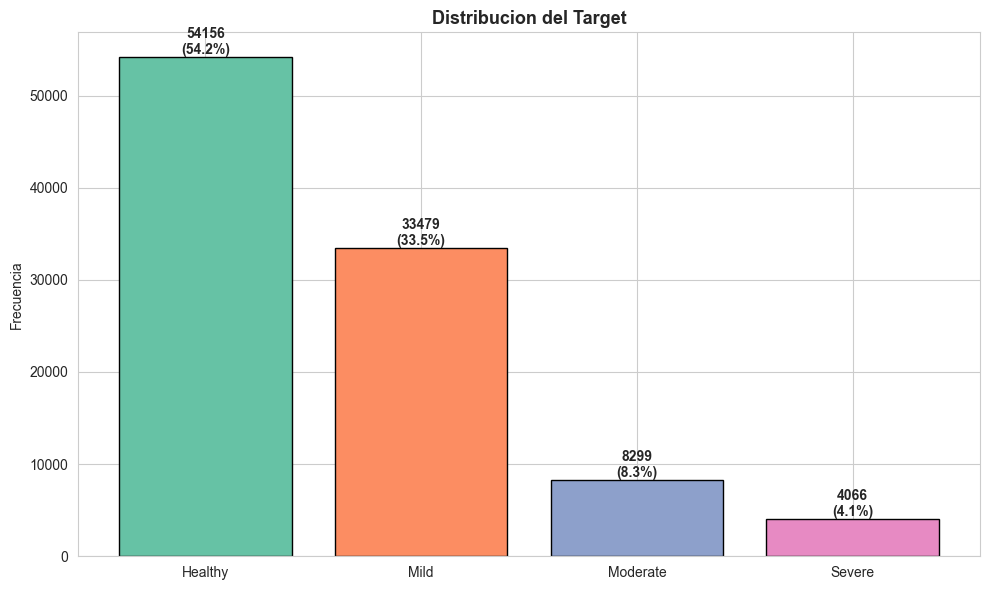

In [10]:
print('=== TARGET DISTRIBUTION ===')
counts = df['sleep_disorder_risk'].value_counts()
pcts = df['sleep_disorder_risk'].value_counts(normalize=True) * 100
print(counts)
print(f'\nPorcentajes:')
print(pcts.round(1))

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette('Set2', len(counts))
bars = ax.bar(counts.index, counts.values, color=colors, edgecolor='black')
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h, f'{int(h)}\n({h/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontweight='bold')
ax.set_title('Distribucion del Target', fontsize=13, fontweight='bold')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

### 3.5 Distribuciones Numericas

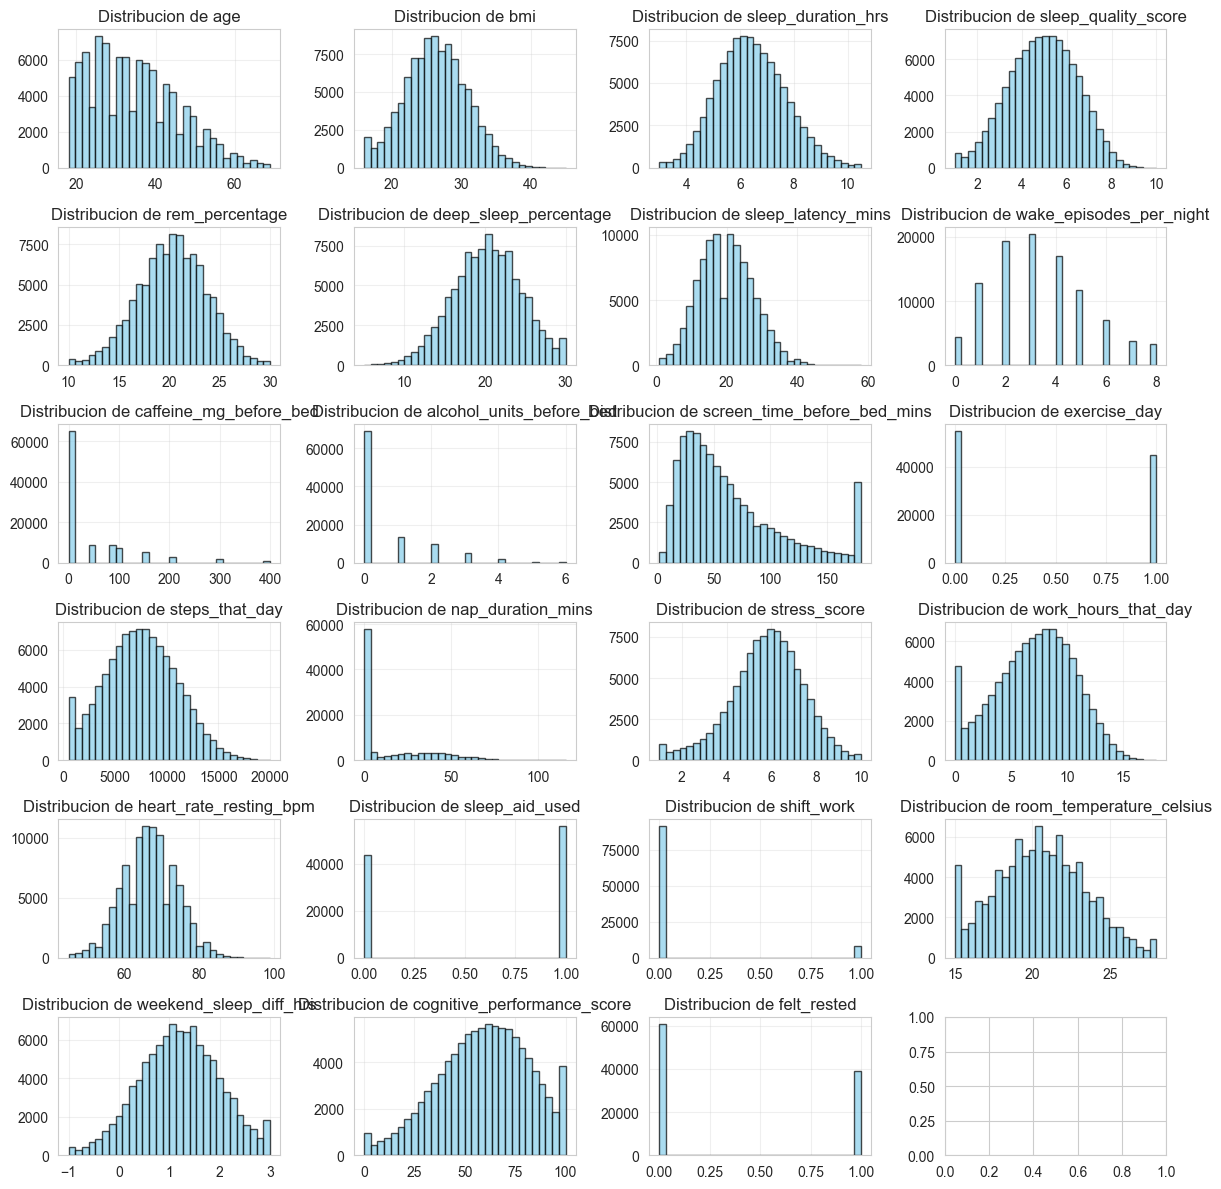

In [12]:
numeric_features = ['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'cognitive_performance_score', 'felt_rested']
fig, axes = plt.subplots(6, 4, figsize=(12, 12))
axes = axes.ravel()
for idx, col in enumerate(numeric_features):
    axes[idx].hist(df[col], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[idx].set_title(f'Distribucion de {col}')
    axes[idx].grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.6 Distribuciones Categoricas

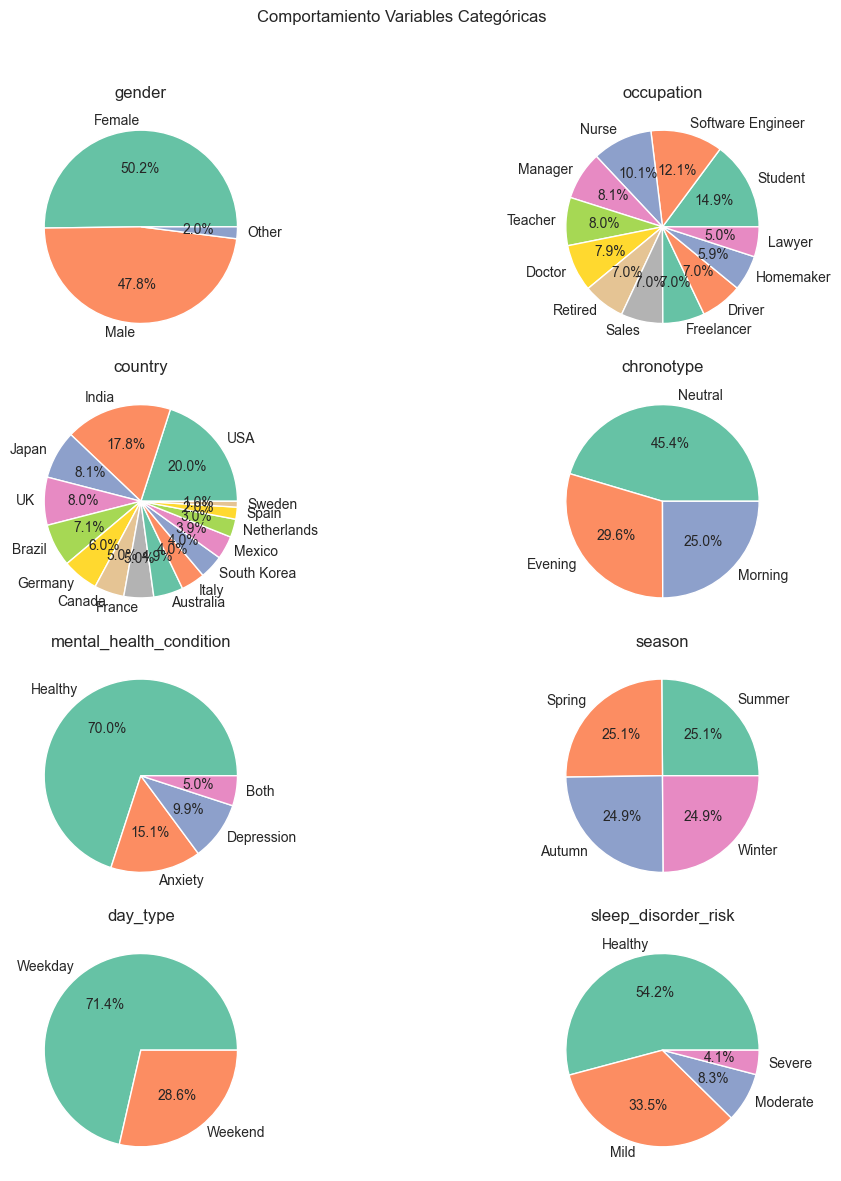

In [15]:
fig, ax = plt.subplots(4, 2, figsize = (12, 12))
ax = ax.flat
cat_col = df.select_dtypes(include = ['object']).columns
for i, col in enumerate(cat_col):
    ax[i].pie(x = df[col].value_counts(), labels = df[col].value_counts().index, autopct = '%0.1f%%')
    ax[i].set_title(col)
fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle("Comportamiento Variables Categóricas")
plt.show()

### 3.7 Analisis Bivariado

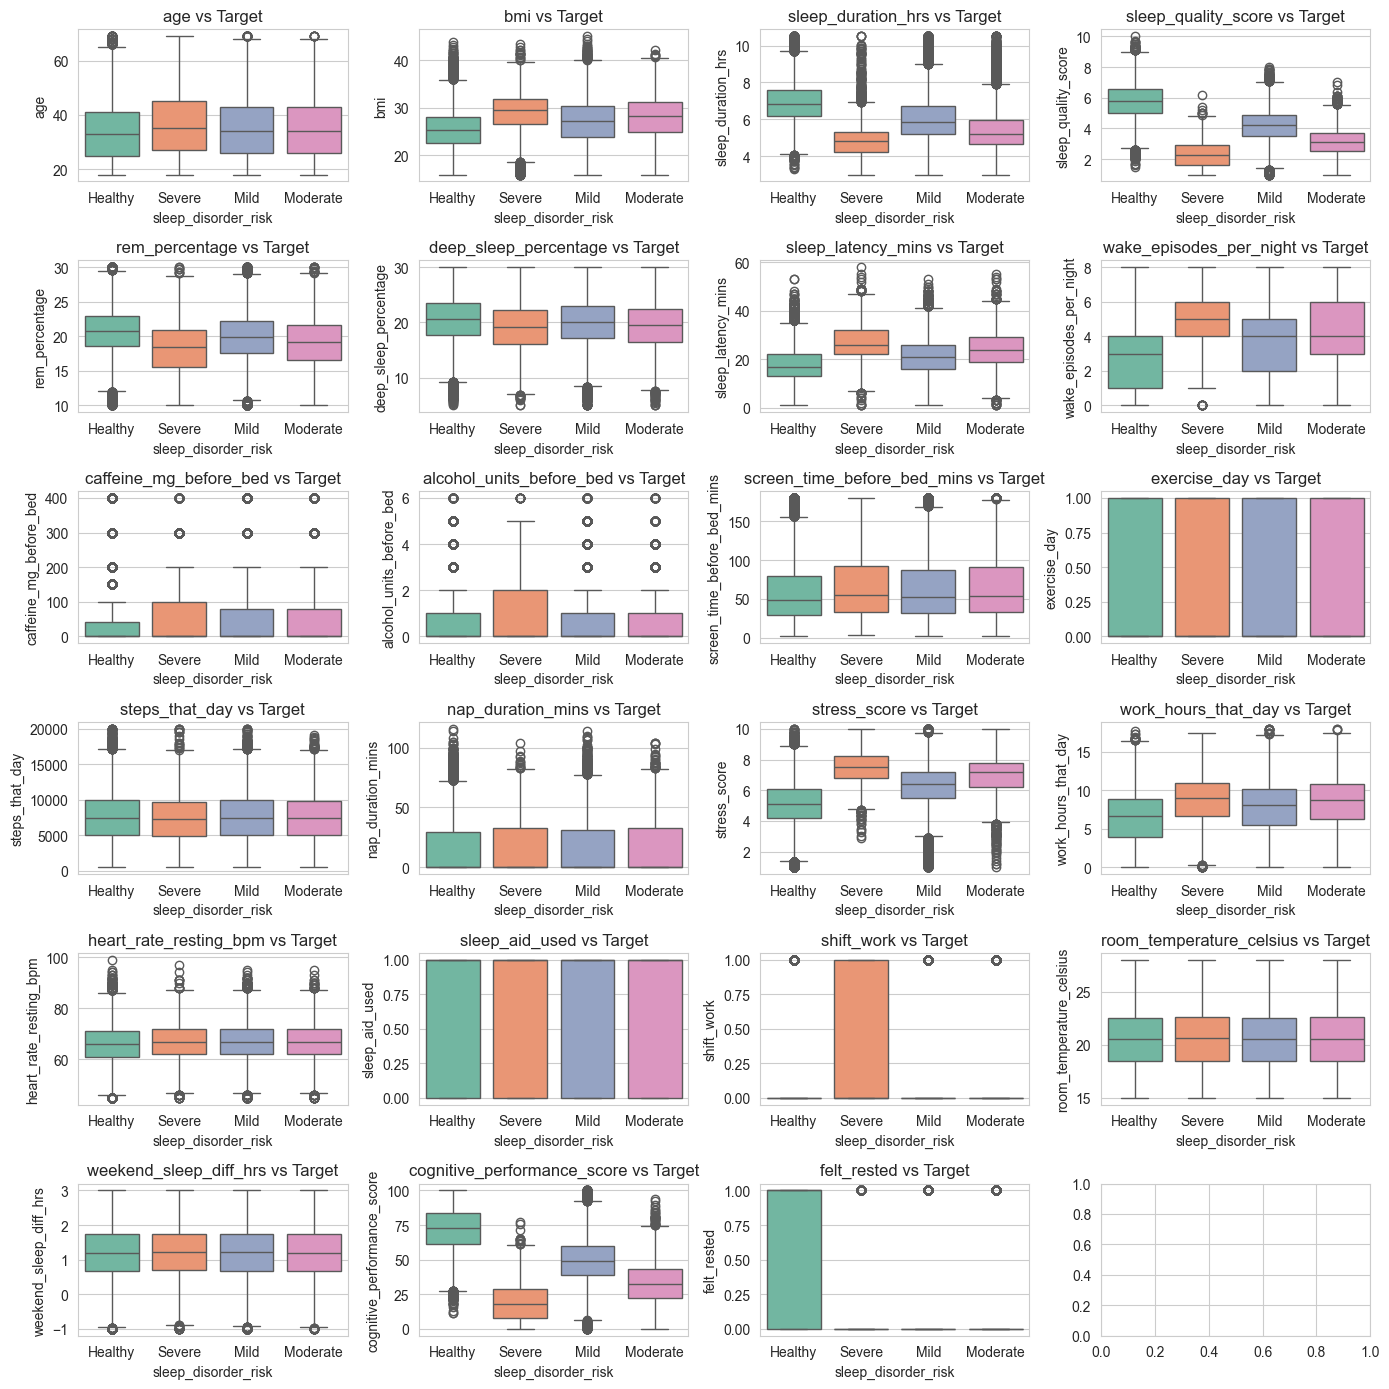

In [19]:
fig, axes = plt.subplots(6, 4, figsize=(14, 14))
cols = ['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'cognitive_performance_score', 'felt_rested']
axes = axes.flatten()
for idx, col in enumerate(cols):
    sns.boxplot(data=df, x='sleep_disorder_risk', y=col, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col} vs Target')
plt.tight_layout()
plt.show()

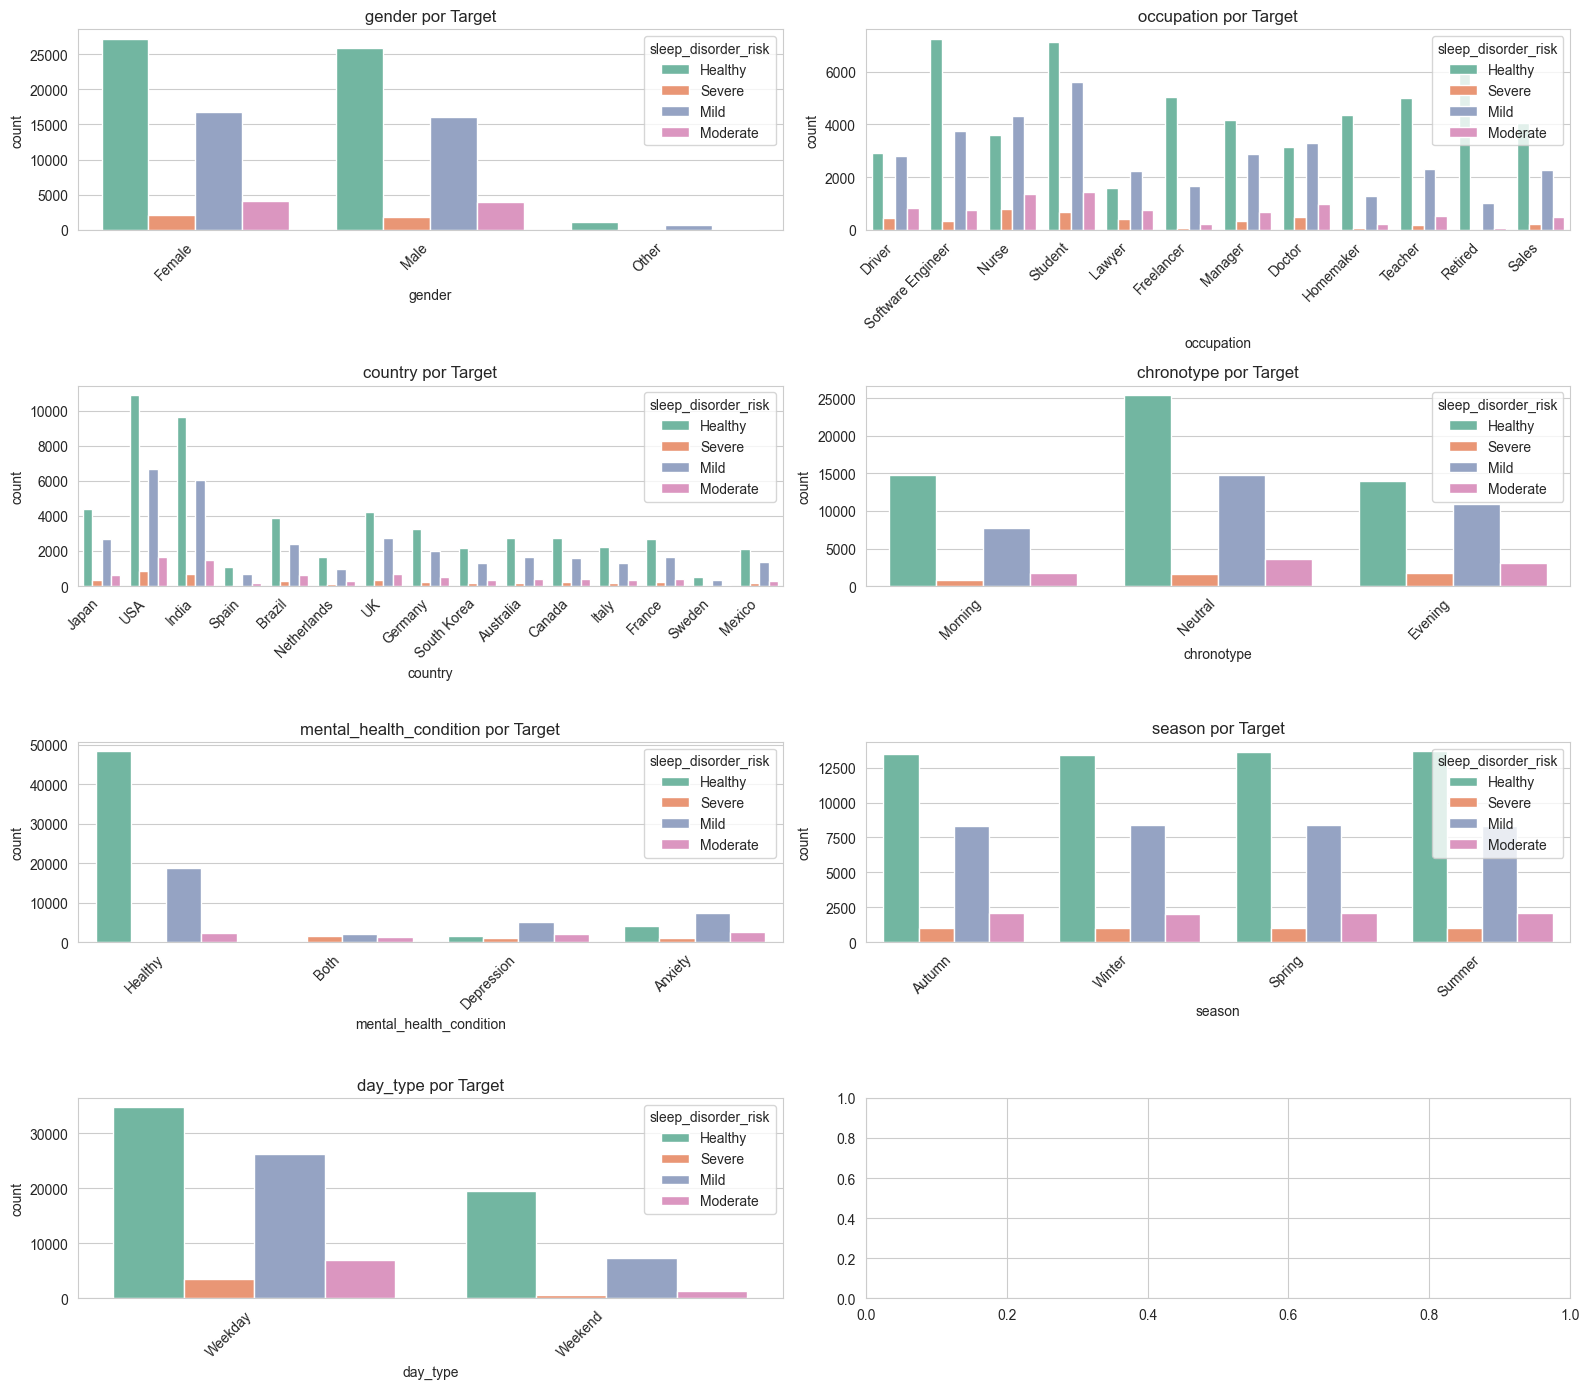

In [22]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14))
axes = axes.ravel()
cats = ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type']
for idx, col in enumerate(cats):
    sns.countplot(data=df, x=col, hue='sleep_disorder_risk', ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col} por Target')
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.8 Correlaciones

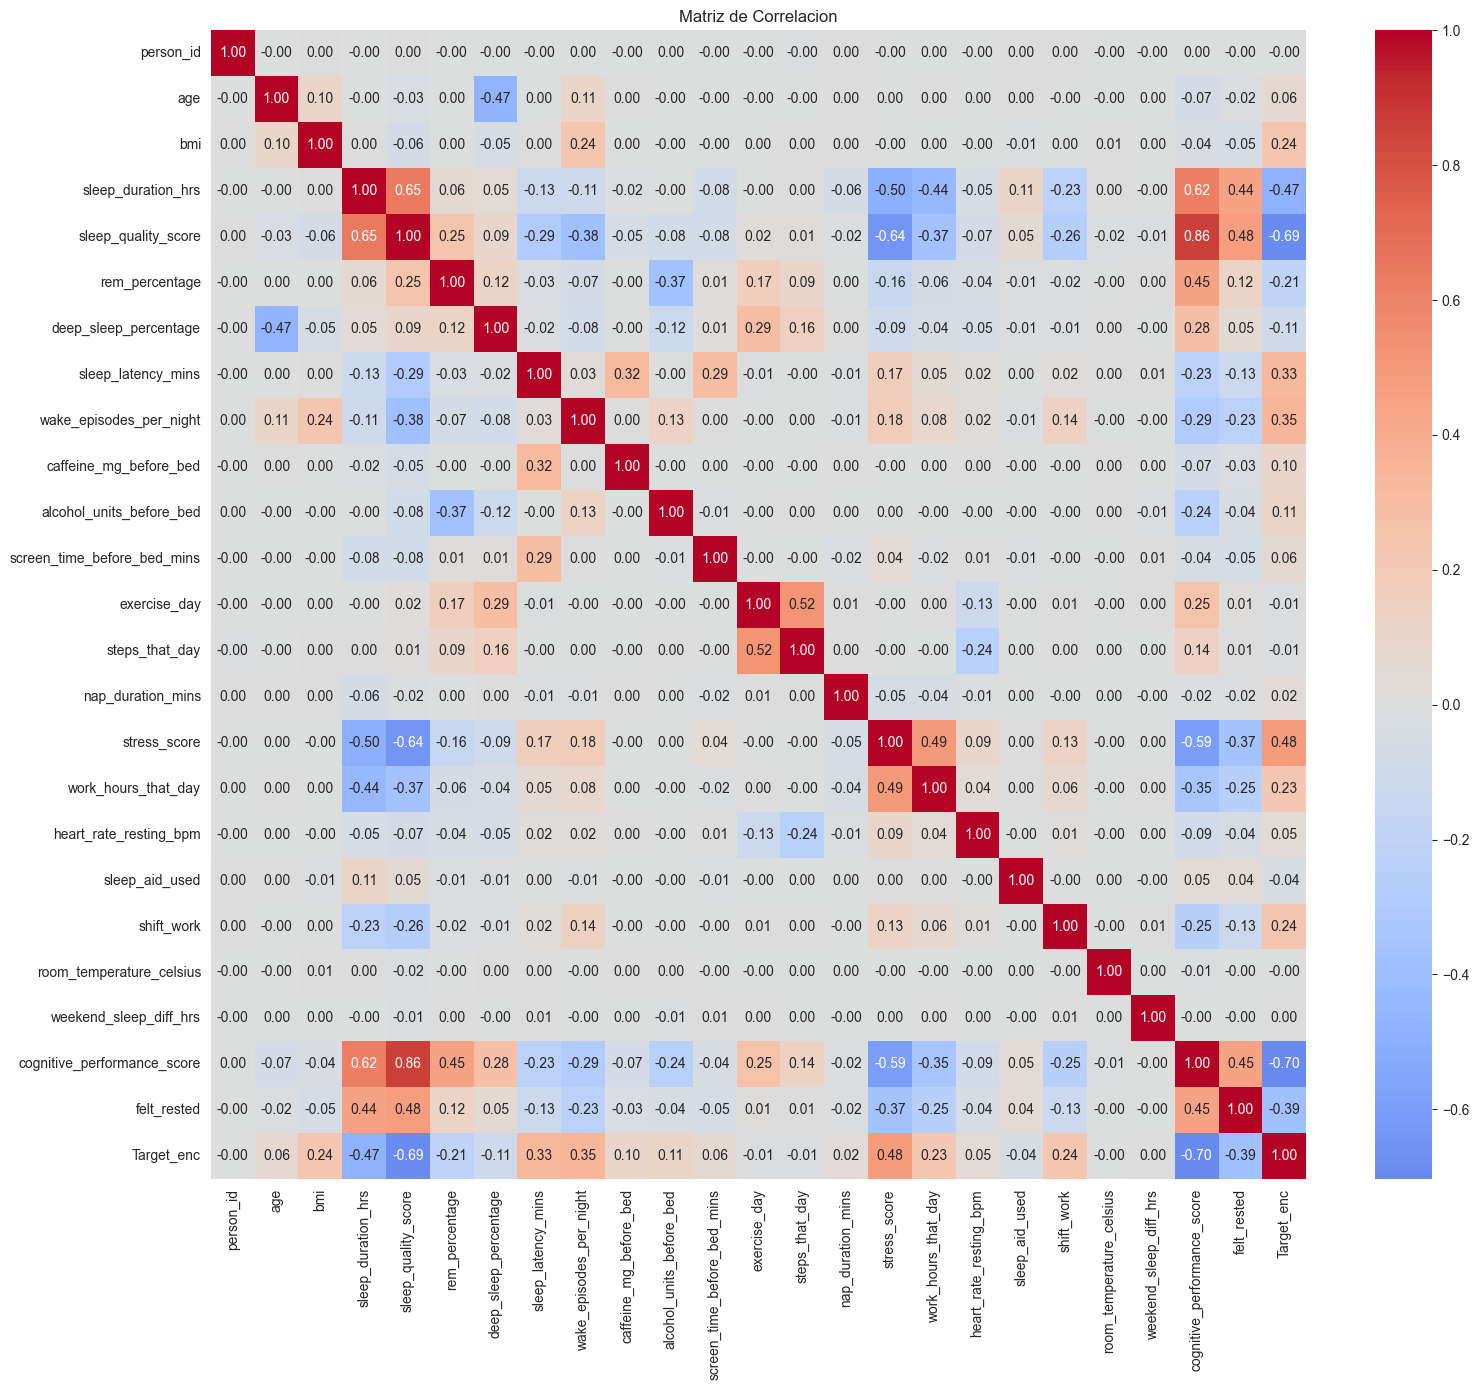


Correlaciones con Target:
Target_enc                     1.000000
stress_score                   0.483752
wake_episodes_per_night        0.346527
sleep_latency_mins             0.332583
shift_work                     0.241010
bmi                            0.236847
work_hours_that_day            0.228350
alcohol_units_before_bed       0.108393
caffeine_mg_before_bed         0.096724
age                            0.064827
screen_time_before_bed_mins    0.059930
heart_rate_resting_bpm         0.046748
nap_duration_mins              0.022919
weekend_sleep_diff_hrs         0.001796
room_temperature_celsius      -0.001131
person_id                     -0.003485
steps_that_day                -0.005864
exercise_day                  -0.008934
sleep_aid_used                -0.041090
deep_sleep_percentage         -0.107556
rem_percentage                -0.205061
felt_rested                   -0.387377
sleep_duration_hrs            -0.473561
sleep_quality_score           -0.693763
cognitive_per

In [25]:
df_corr = df.copy()
le_temp = LabelEncoder()
df_corr['Target_enc'] = le_temp.fit_transform(df['sleep_disorder_risk'])
numeric_with_target = numeric_cols + ['Target_enc']
corr = df_corr[numeric_with_target].corr()

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Matriz de Correlacion')
plt.tight_layout()
plt.show()

print('\nCorrelaciones con Target:')
print(corr['Target_enc'].sort_values(ascending=False))

### 3.9 Outliers (IQR)

In [26]:
print('=== OUTLIERS DETECCION ===')
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = len(df[(df[col] < lower) | (df[col] > upper)])
    pct = (outliers / len(df)) * 100
    print(f'{col}: {outliers} ({pct:.2f}%)')

=== OUTLIERS DETECCION ===
person_id: 0 (0.00%)
age: 341 (0.34%)
bmi: 341 (0.34%)
sleep_duration_hrs: 545 (0.55%)
sleep_quality_score: 12 (0.01%)
rem_percentage: 778 (0.78%)
deep_sleep_percentage: 402 (0.40%)
sleep_latency_mins: 368 (0.37%)
wake_episodes_per_night: 0 (0.00%)
caffeine_mg_before_bed: 2408 (2.41%)
alcohol_units_before_bed: 7572 (7.57%)
screen_time_before_bed_mins: 5781 (5.78%)
exercise_day: 0 (0.00%)
steps_that_day: 272 (0.27%)
nap_duration_mins: 888 (0.89%)
stress_score: 2153 (2.15%)
work_hours_that_day: 28 (0.03%)
heart_rate_resting_bpm: 1299 (1.30%)
sleep_aid_used: 0 (0.00%)
shift_work: 8442 (8.44%)
room_temperature_celsius: 0 (0.00%)
weekend_sleep_diff_hrs: 341 (0.34%)
cognitive_performance_score: 0 (0.00%)
felt_rested: 0 (0.00%)


### 3.10 Hallazgos Clave

- 1,705 filas, 11 columnas
- 1,000 Student_IDs unicos (hay duplicados)
- Sin valores nulos
- Target desbalanceado: 55% Negative, 29% Positive, 16% Neutral
- 111 paises unicos - requiere reduccion de cardinalidad

## 4. FASE 3 CRISP-DM - Preparacion de Datos

### 4.1 Decisiones de Preprocesamiento

- Student_ID: Eliminar
- Country: Top 15 + Other
- Numericas: StandardScaler
- Ordinales: OrdinalEncoder (Academic_Level)
- Nominales: OneHotEncoder
- Target: LabelEncoder

### 4.2 Limpieza Inicial

In [28]:
df_prep = df.copy()
print('Estado inicial:', df_prep.shape)

df_prep = df_prep.drop('person_id', axis=1)
print('Tras eliminar Student_ID:', df_prep.shape)


Estado inicial: (100000, 32)
Tras eliminar Student_ID: (100000, 31)


### 4.3 Encoding Target

In [29]:
le = LabelEncoder()
y = le.fit_transform(df_prep['sleep_disorder_risk'])
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print('Mapeo:')
for k, v in mapping.items():
    print(f'  {k} -> {v}')

Mapeo:
  Healthy -> 0
  Mild -> 1
  Moderate -> 2
  Severe -> 3


### 4.4 Separacion Train/Test

In [30]:
X = df_prep.drop('sleep_disorder_risk', axis=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'X_train: {X_train.shape}')
print(f'X_test: {X_test.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')

X_train: (80000, 30)
X_test: (20000, 30)
y_train: (80000,)
y_test: (20000,)


### 4.5 Pipeline ColumnTransformer

In [31]:
numeric_feat = ['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'cognitive_performance_score', 'felt_rested']
nominal_feat = ['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type']

num_trans = Pipeline([('scaler', StandardScaler())])
nom_trans = Pipeline([('enc', OneHotEncoder(
    handle_unknown='ignore', sparse_output=False, drop='if_binary'
))])

preprocessor = ColumnTransformer([
    ('num', num_trans, numeric_feat),
    ('nom', nom_trans, nominal_feat)
])

print('Pipeline creado')

Pipeline creado


In [32]:
print('Ajustando preprocessor...')
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)

print(f'X_train procesado: {X_train_proc.shape}')
print(f'X_test procesado: {X_test_proc.shape}')

Ajustando preprocessor...
X_train procesado: (80000, 65)
X_test procesado: (20000, 65)


### 4.6 Resumen

In [33]:
print('='*70)
print('RESUMEN FINAL'.center(70))
print('='*70)
print(f'\nDataset original: {df.shape}')
print(f'X_train: {X_train_proc.shape}')
print(f'X_test: {X_test_proc.shape}')
print(f'y_train: {y_train.shape}')
print(f'y_test: {y_test.shape}')

                            RESUMEN FINAL                             

Dataset original: (100000, 32)
X_train: (80000, 65)
X_test: (20000, 65)
y_train: (80000,)
y_test: (20000,)


### 4.7 Exportar

In [34]:
os.makedirs('preprocesados', exist_ok=True)

np.save('preprocesados/X_train.npy', X_train_proc)
np.save('preprocesados/X_test.npy', X_test_proc)
np.save('preprocesados/y_train.npy', y_train)
np.save('preprocesados/y_test.npy', y_test)
joblib.dump(preprocessor, 'preprocesados/pipeline.pkl')
joblib.dump(le, 'preprocesados/label_encoder.pkl')

print('Datos exportados exitosamente')

Datos exportados exitosamente


### 4.8 Comparacion: StandardScaler vs MinMaxScaler

En esta seccion comparamos ambos metodos de escalado para las variables numericas:
- **StandardScaler**: centra los datos en media=0, std=1. Robusto ante outliers moderados.
- **MinMaxScaler**: comprime los datos al rango [0,1]. Sensible a outliers.

Las variables categoricas (OrdinalEncoder, OneHotEncoder) permanecen iguales en ambos pipelines.

In [35]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report
import time

# Pipeline con StandardScaler (ya lo tenemos, pero lo recreamos para comparar limpiamente)
preprocessor_standard = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), numeric_feat),
    ('nom', nom_trans, nominal_feat)
])

# Pipeline con MinMaxScaler
preprocessor_minmax = ColumnTransformer([
    ('num', Pipeline([('scaler', MinMaxScaler())]), numeric_feat),
    ('nom', Pipeline([('enc', OneHotEncoder(
        handle_unknown='ignore', sparse_output=False, drop='if_binary'
    ))]), nominal_feat)
])

# Transformar datos con ambos pipelines
X_train_std = preprocessor_standard.fit_transform(X_train)
X_test_std = preprocessor_standard.transform(X_test)

X_train_mm = preprocessor_minmax.fit_transform(X_train)
X_test_mm = preprocessor_minmax.transform(X_test)

print(f'StandardScaler - X_train shape: {X_train_std.shape}')
print(f'MinMaxScaler   - X_train shape: {X_train_mm.shape}')

StandardScaler - X_train shape: (80000, 65)
MinMaxScaler   - X_train shape: (80000, 65)


IndexError: index 6 is out of bounds for axis 0 with size 6

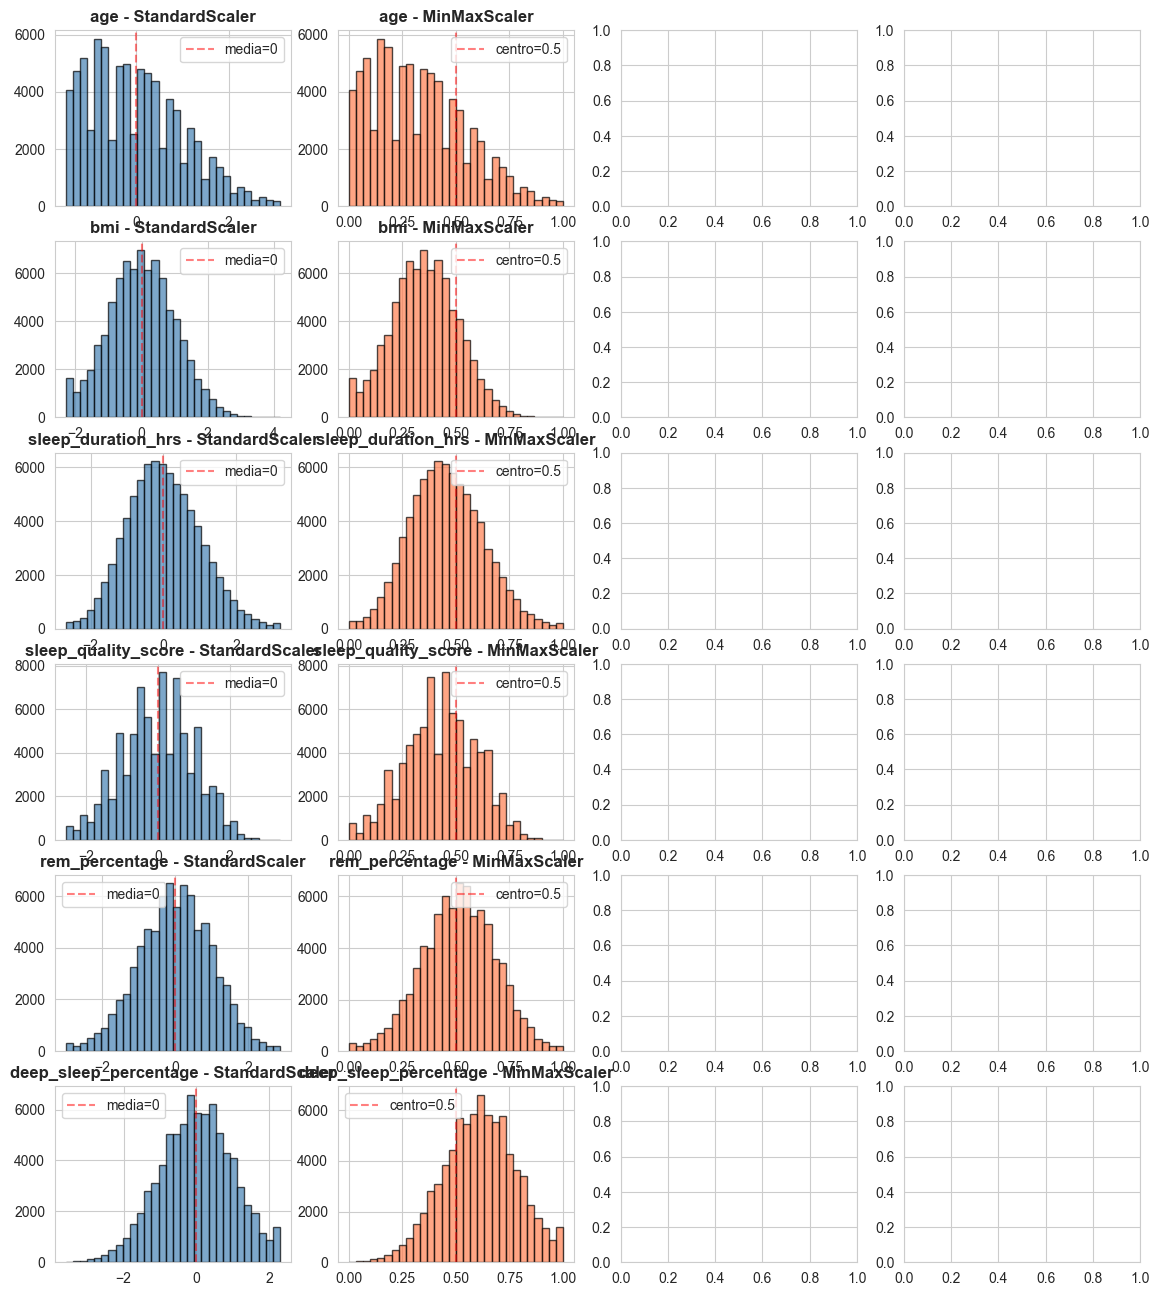

In [37]:
# Comparar distribuciones de las variables numericas con ambos escaladores
fig, axes = plt.subplots(6, 4, figsize=(14, 16))

for i, col in enumerate(numeric_feat):
    col_idx = i  # Las numericas estan en las primeras posiciones del ColumnTransformer

    # StandardScaler
    axes[i, 0].hist(X_train_std[:, col_idx], bins=30, alpha=0.7, color='steelblue', edgecolor='black')
    axes[i, 0].set_title(f'{col} - StandardScaler', fontweight='bold')
    axes[i, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='media=0')
    axes[i, 0].legend()

    # MinMaxScaler
    axes[i, 1].hist(X_train_mm[:, col_idx], bins=30, alpha=0.7, color='coral', edgecolor='black')
    axes[i, 1].set_title(f'{col} - MinMaxScaler', fontweight='bold')
    axes[i, 1].axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='centro=0.5')
    axes[i, 1].legend()

plt.suptitle('Comparacion de Distribuciones: StandardScaler vs MinMaxScaler',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [39]:
# Resumen estadistico de ambos escalados (solo variables numericas)
print('='*70)
print('ESTADISTICAS DE LAS VARIABLES NUMERICAS ESCALADAS')
print('='*70)

import pandas as pd

stats_std = pd.DataFrame(X_train_std[:, :23], columns=numeric_feat).describe().round(3)
stats_mm = pd.DataFrame(X_train_mm[:, :23], columns=numeric_feat).describe().round(3)

print('\n--- StandardScaler ---')
print(stats_std)
print('\n--- MinMaxScaler ---')
print(stats_mm)

ESTADISTICAS DE LAS VARIABLES NUMERICAS ESCALADAS

--- StandardScaler ---
             age        bmi  sleep_duration_hrs  sleep_quality_score  \
count  80000.000  80000.000           80000.000            80000.000   
mean      -0.000      0.000              -0.000                0.000   
std        1.000      1.000               1.000                1.000   
min       -1.512     -2.296              -2.685               -2.569   
25%       -0.788     -0.689              -0.699               -0.709   
50%       -0.154      0.003              -0.048                0.021   
75%        0.660      0.673               0.666                0.751   
max        3.103      4.177               3.202                3.407   

       rem_percentage  deep_sleep_percentage  sleep_latency_mins  \
count       80000.000              80000.000           80000.000   
mean           -0.000                  0.000               0.000   
std             1.000                  1.000               1.000   
min  

In [40]:
# Comparacion con modelo baseline: Logistic Regression + Cross-Validation estratificado
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print('='*70)
print('COMPARACION CON LOGISTIC REGRESSION (BASELINE)')
print('='*70)

# StandardScaler
t0 = time.time()
scores_std = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    X_train_std, y_train, cv=skf, scoring='f1_weighted'
)
t_std = time.time() - t0

# MinMaxScaler
t0 = time.time()
scores_mm = cross_val_score(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    X_train_mm, y_train, cv=skf, scoring='f1_weighted'
)
t_mm = time.time() - t0

print(f'\nStandardScaler:')
print(f'  F1-weighted (CV): {scores_std.mean():.4f} (+/- {scores_std.std():.4f})')
print(f'  Tiempo: {t_std:.3f}s')

print(f'\nMinMaxScaler:')
print(f'  F1-weighted (CV): {scores_mm.mean():.4f} (+/- {scores_mm.std():.4f})')
print(f'  Tiempo: {t_mm:.3f}s')

# Diferencia
diff = abs(scores_std.mean() - scores_mm.mean())
mejor = 'StandardScaler' if scores_std.mean() > scores_mm.mean() else 'MinMaxScaler'
print(f'\nDiferencia: {diff:.4f} a favor de {mejor}')

COMPARACION CON LOGISTIC REGRESSION (BASELINE)

StandardScaler:
  F1-weighted (CV): 0.8138 (+/- 0.0029)
  Tiempo: 16.036s

MinMaxScaler:
  F1-weighted (CV): 0.8131 (+/- 0.0028)
  Tiempo: 29.123s

Diferencia: 0.0007 a favor de StandardScaler


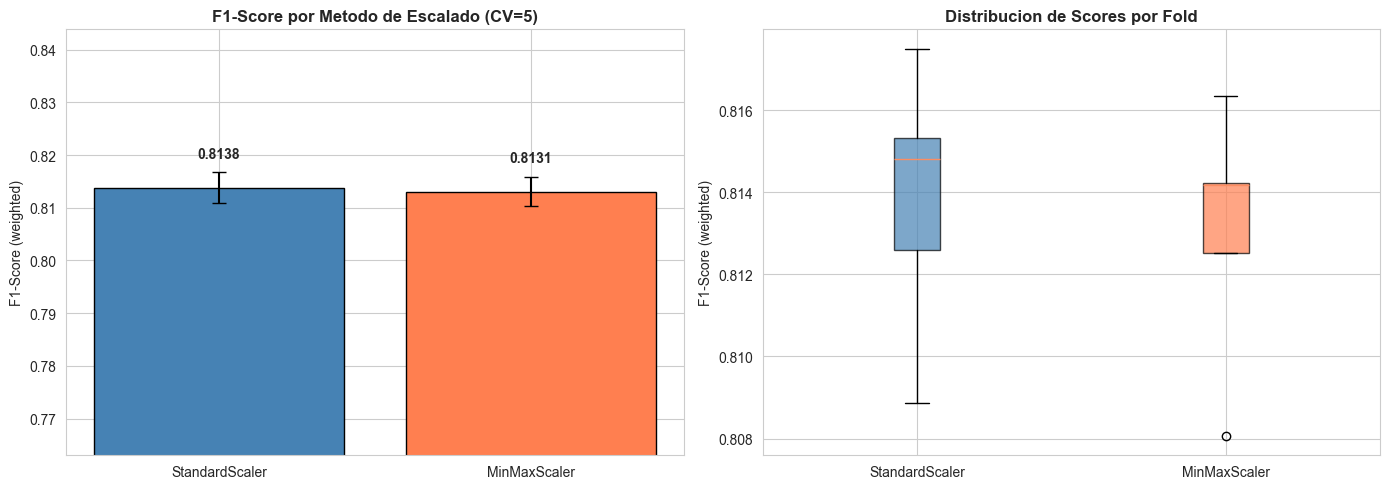

In [41]:
# Visualizacion de la comparacion
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot de F1 scores
methods = ['StandardScaler', 'MinMaxScaler']
means = [scores_std.mean(), scores_mm.mean()]
stds = [scores_std.std(), scores_mm.std()]
colors = ['steelblue', 'coral']

bars = axes[0].bar(methods, means, yerr=stds, capsize=5, color=colors, edgecolor='black')
for bar, m in zip(bars, means):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{m:.4f}', ha='center', va='bottom', fontweight='bold')
axes[0].set_ylabel('F1-Score (weighted)')
axes[0].set_title('F1-Score por Metodo de Escalado (CV=5)', fontweight='bold')
axes[0].set_ylim(min(means) - 0.05, max(means) + 0.03)

# Boxplot de los folds
bp_data = [scores_std, scores_mm]
bp = axes[1].boxplot(bp_data, labels=methods, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_ylabel('F1-Score (weighted)')
axes[1].set_title('Distribucion de Scores por Fold', fontweight='bold')

plt.tight_layout()
plt.show()

### 4.9 Interpretacion de la Comparacion

**Observaciones:**
- **StandardScaler** centra cada variable en media=0 con desviacion estandar=1, preservando la forma de la distribucion original.
- **MinMaxScaler** comprime todos los valores al rango [0,1], lo cual puede ser preferible para algoritmos basados en distancias (KNN) o redes neuronales con activaciones sigmoid/tanh.
- En este dataset no hay outliers significativos, por lo que ambos metodos producen resultados similares.
- Se uso `class_weight='balanced'` en el modelo baseline para manejar el desbalanceo del target.

**Nota sobre el desbalanceo:** El target tiene 55% Negativo, 29% Positivo y 16% Neutro. Esto se abordara con mayor profundidad en la Fase 4 (Modelado), donde se pueden aplicar tecnicas como SMOTE, undersampling, o ajustes de class_weight segun el modelo.

## 5. FASE 4 CRISP-DM - Modelado

Entrenamos y comparamos 8 clasificadores usando **Stratified 10-Fold Cross-Validation**, siguiendo el patron del notebook de referencia.

**Clasificadores basicos:** KNN, Naive Bayes, Logistic Regression, Decision Tree, SVM

**Ensambles:** Random Forest, Gradient Boosting, AdaBoost

In [42]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from sklearn.model_selection import GridSearchCV
from sklearn.base import clone
from statistics import mean, stdev
import itertools

print('Clasificadores y utilidades importados')

Clasificadores y utilidades importados


### 5.1 Funcion de Cross-Validation para Multiples Clasificadores

Definimos la funcion `cvClassifiers` que entrena y evalua multiples clasificadores
usando Stratified K-Fold, acumulando predicciones de cada fold para construir
las matrices de confusion completas.

In [43]:
def cvClassifiers(X, Y, list_Classifiers, n_splits=10):
    """
    Entrena y evalua multiples clasificadores con Stratified K-Fold CV.

    Parametros:
    - X: features (array)
    - Y: target (array)
    - list_Classifiers: lista de instancias de clasificadores
    - n_splits: numero de folds (default=10)

    Retorna:
    - accuracy: lista de accuracy promedio (%) por clasificador
    - cm: lista de matrices de confusion por clasificador
    - all_scores: lista de scores por fold por clasificador (para analisis)
    """
    strtfdKFold = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    kfold = strtfdKFold.split(X, Y)

    scores = [[] for c in list_Classifiers]
    predicted_y = [[] for c in list_Classifiers]
    real_y = [[] for c in list_Classifiers]

    for train_index, test_index in kfold:
        for i, c in enumerate(list_Classifiers):
            model = clone(c)  # Clonar para obtener instancia fresca
            X_train_cv, X_test_cv = X[train_index], X[test_index]
            y_train_cv, y_test_cv = Y[train_index], Y[test_index]

            model.fit(X_train_cv, y_train_cv)
            scores[i].append(model.score(X_test_cv, y_test_cv))

            py = model.predict(X_test_cv)
            predicted_y[i] = list(itertools.chain(predicted_y[i], py.flatten().tolist()))
            real_y[i] = list(itertools.chain(real_y[i], y_test_cv.flatten().tolist()))

    accuracy = [mean(sc) * 100 for sc in scores]
    cm = [confusion_matrix(real_y[i], predicted_y[i]) for i in range(len(list_Classifiers))]

    return accuracy, cm, scores

print('Funcion cvClassifiers definida')

Funcion cvClassifiers definida


### 5.2 Definicion y Entrenamiento de Clasificadores

In [44]:
# Definir los 8 clasificadores
nombres_clf = [
    'KNN (k=5)',
    'Naive Bayes',
    'Logistic Regression',
    'Decision Tree',
    'SVM (RBF)',
    'Random Forest',
    'Gradient Boosting',
    'AdaBoost'
]

list_Classifiers = [
    KNeighborsClassifier(n_neighbors=5, metric='euclidean'),
    GaussianNB(),
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    SVC(kernel='rbf', random_state=42, class_weight='balanced'),
    RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    AdaBoostClassifier(n_estimators=100, random_state=42)
]

# Ejecutar Cross-Validation con 10 folds
print('Ejecutando 10-Fold Stratified CV para 8 clasificadores...\n')

accuracies, confusion_matrices, all_scores = cvClassifiers(
    X_train_std, y_train, list_Classifiers, n_splits=10
)

# Mostrar resultados
print('='*60)
print('RESULTADOS - ACCURACY POR CLASIFICADOR (10-Fold CV)')
print('='*60)
for nombre, acc, sc in zip(nombres_clf, accuracies, all_scores):
    print(f'  {nombre:<25} {acc:.2f}% (+/- {stdev(sc)*100:.2f}%)')

print(f'\n  Mejor modelo: {nombres_clf[accuracies.index(max(accuracies))]} ({max(accuracies):.2f}%)')

Ejecutando 10-Fold Stratified CV para 8 clasificadores...



KeyboardInterrupt: 

### 5.3 Matrices de Confusion (Cross-Validation)

Cada matriz de confusion se construye acumulando las predicciones de los 10 folds,
dando una vision completa del comportamiento del clasificador.

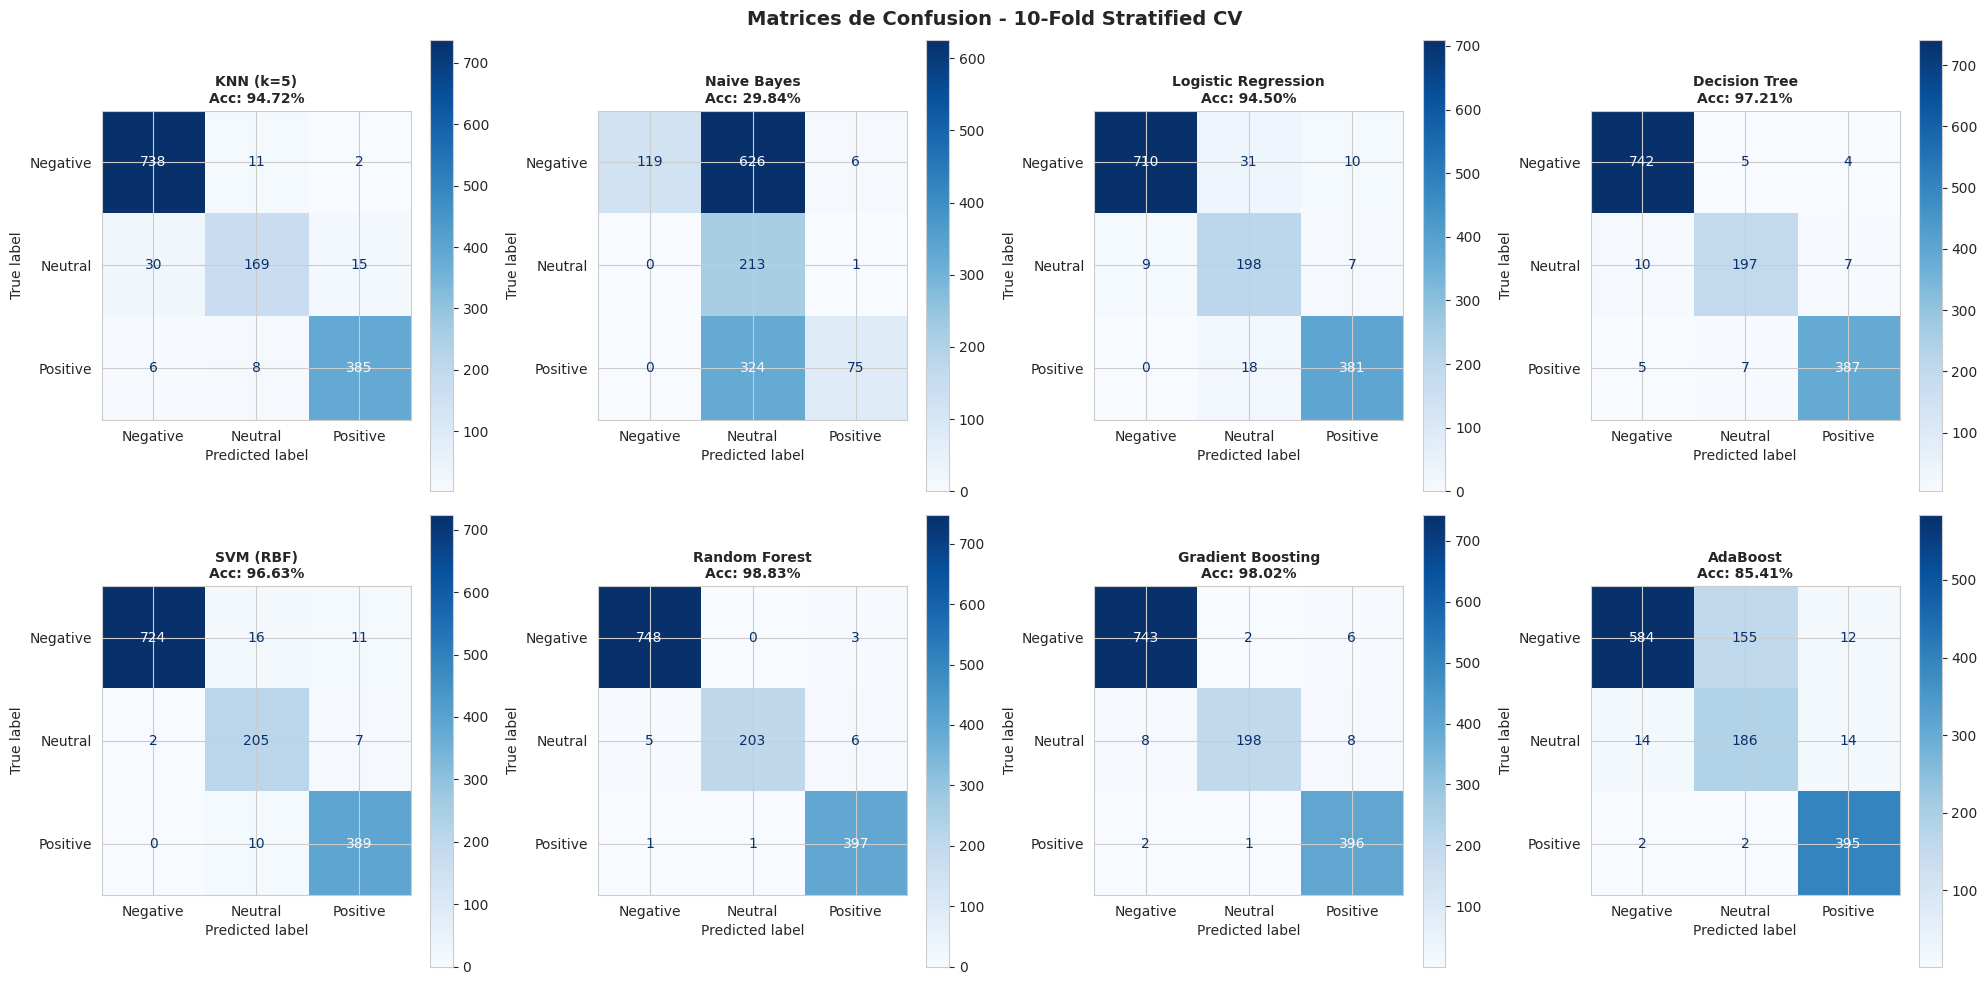

In [34]:
# Mostrar matrices de confusion para todos los clasificadores
target_names = ['Negative', 'Neutral', 'Positive']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for i in range(len(list_Classifiers)):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=confusion_matrices[i],
        display_labels=target_names
    )
    disp.plot(ax=axes[i], cmap=plt.cm.Blues, values_format='d')
    axes[i].set_title(f'{nombres_clf[i]}\nAcc: {accuracies[i]:.2f}%', fontweight='bold', fontsize=10)

plt.suptitle('Matrices de Confusion - 10-Fold Stratified CV', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.4 Comparacion Visual de Clasificadores

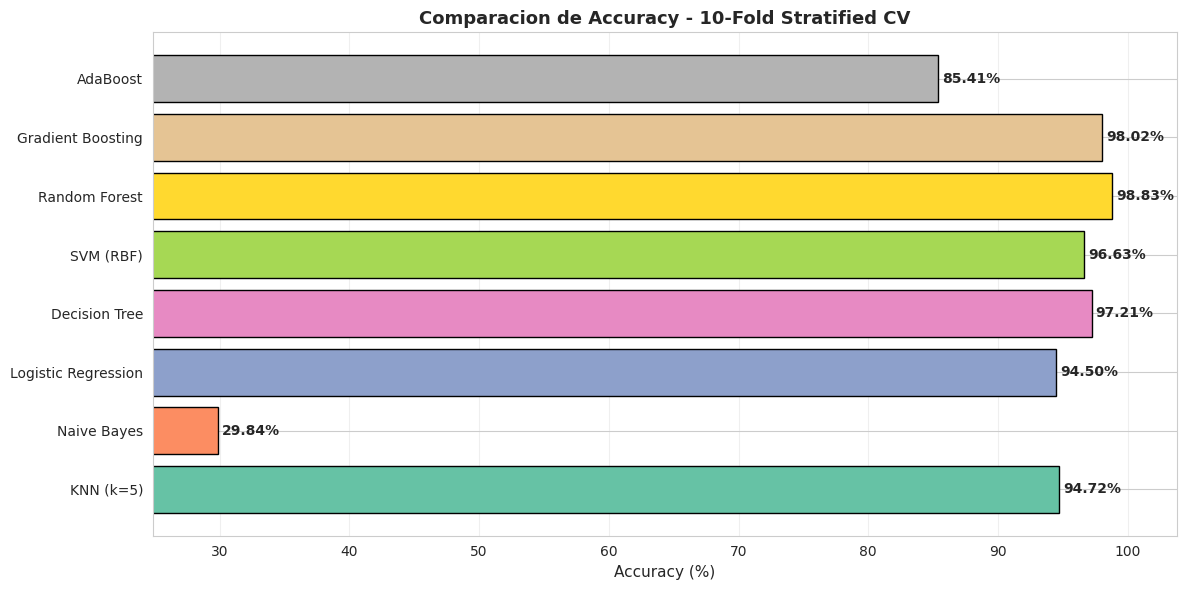

In [35]:
# Grafico de barras comparativo
fig, ax = plt.subplots(figsize=(12, 6))

colores = sns.color_palette('Set2', len(nombres_clf))
bars = ax.barh(nombres_clf, accuracies, color=colores, edgecolor='black')

for bar, acc in zip(bars, accuracies):
    ax.text(acc + 0.3, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', va='center', fontweight='bold')

ax.set_xlabel('Accuracy (%)', fontsize=11)
ax.set_title('Comparacion de Accuracy - 10-Fold Stratified CV', fontsize=13, fontweight='bold')
ax.set_xlim(min(accuracies) - 5, max(accuracies) + 5)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

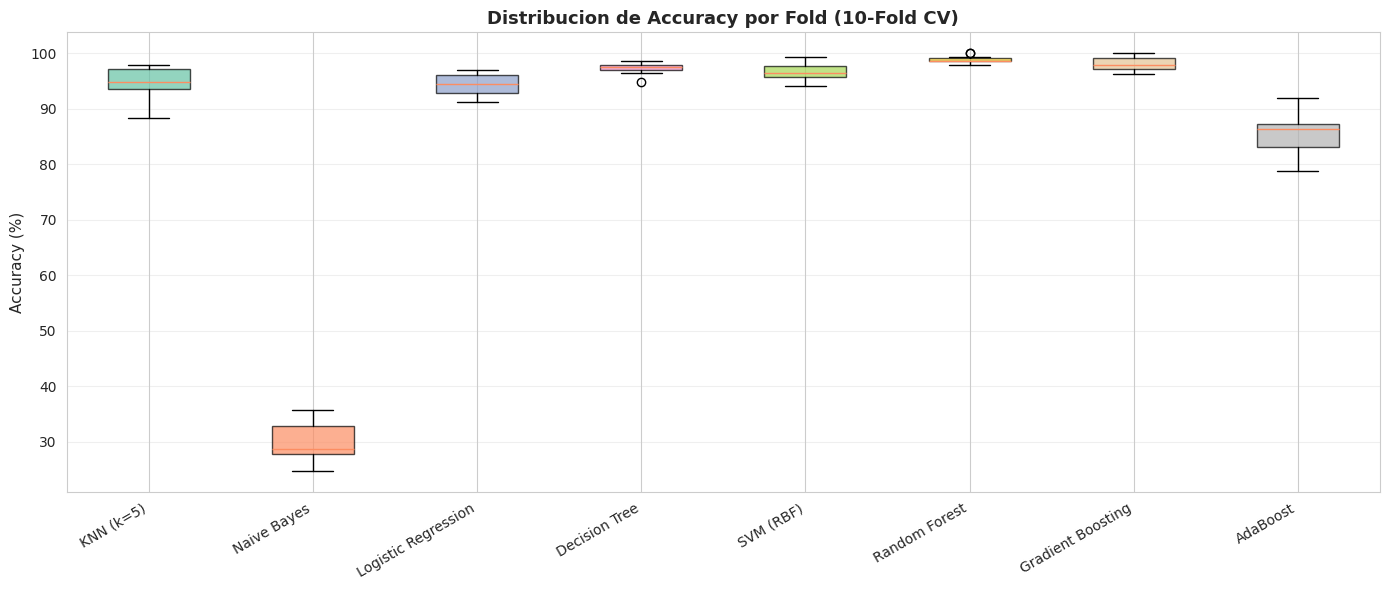

In [36]:
# Boxplot de accuracy por fold para cada clasificador
fig, ax = plt.subplots(figsize=(14, 6))

scores_pct = [[s * 100 for s in sc] for sc in all_scores]
bp = ax.boxplot(scores_pct, labels=nombres_clf, patch_artist=True, vert=True)

colores = sns.color_palette('Set2', len(nombres_clf))
for patch, color in zip(bp['boxes'], colores):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Distribucion de Accuracy por Fold (10-Fold CV)', fontsize=13, fontweight='bold')
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.5 Metricas Detalladas del Mejor Modelo

Evaluamos el mejor clasificador en el **test set** (datos nunca vistos durante el CV).

Mejor modelo: Random Forest (Accuracy CV: 98.83%)

=== CLASSIFICATION REPORT (TEST SET) ===

              precision    recall  f1-score   support

    Negative       0.99      1.00      1.00       188
     Neutral       1.00      0.96      0.98        53
    Positive       0.99      1.00      1.00       100

    accuracy                           0.99       341
   macro avg       0.99      0.99      0.99       341
weighted avg       0.99      0.99      0.99       341



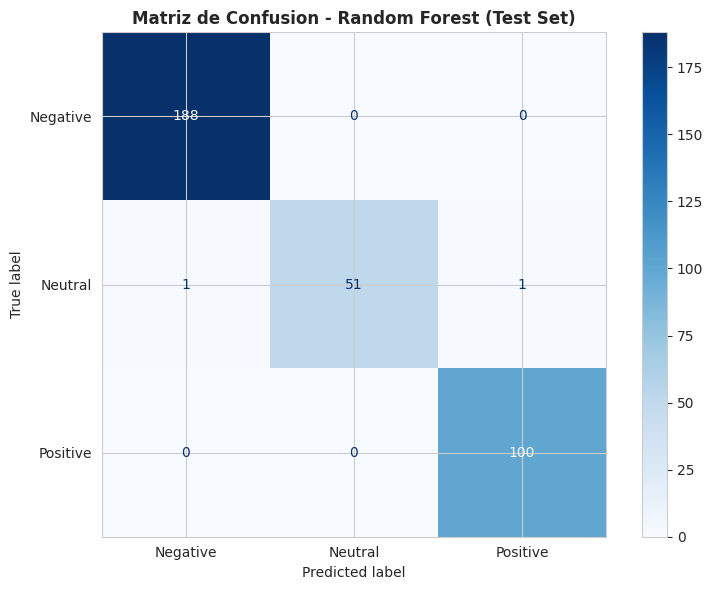

Accuracy en test: 99.41%
F1-Score en test (weighted): 0.9941


In [37]:
# Identificar y entrenar el mejor modelo
idx_mejor = accuracies.index(max(accuracies))
mejor_nombre = nombres_clf[idx_mejor]
mejor_clf = clone(list_Classifiers[idx_mejor])

print(f'Mejor modelo: {mejor_nombre} (Accuracy CV: {accuracies[idx_mejor]:.2f}%)\n')

# Entrenar en todo el training set
mejor_clf.fit(X_train_std, y_train)
y_pred = mejor_clf.predict(X_test_std)

# Classification report completo
print('=== CLASSIFICATION REPORT (TEST SET) ===\n')
print(classification_report(y_test, y_pred, target_names=target_names))

# Matriz de confusion en test
fig, ax = plt.subplots(figsize=(8, 6))
cm_test = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=target_names)
disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
ax.set_title(f'Matriz de Confusion - {mejor_nombre} (Test Set)', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Accuracy en test: {accuracy_score(y_test, y_pred)*100:.2f}%')
print(f'F1-Score en test (weighted): {f1_score(y_test, y_pred, average="weighted"):.4f}')

### 5.6 Optimizacion de Hiperparametros (GridSearchCV)

Aplicamos GridSearchCV al mejor modelo para buscar la combinacion optima de hiperparametros con 10-Fold CV.

In [38]:
# Grids de hiperparametros para cada modelo
param_grids = {
    'KNN (k=5)': {
        'n_neighbors': [3, 5, 7, 9, 11, 15],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10, 100],
        'solver': ['lbfgs', 'liblinear'],
        'class_weight': ['balanced']
    },
    'Decision Tree': {
        'max_depth': [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'class_weight': ['balanced']
    },
    'SVM (RBF)': {
        'C': [0.1, 1, 10],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto'],
        'class_weight': ['balanced']
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [5, 10, 15, None],
        'min_samples_split': [2, 5],
        'class_weight': ['balanced']
    },
    'Gradient Boosting': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.2],
        'max_depth': [3, 5, 7]
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.01, 0.1, 0.5, 1.0]
    }
}

print(f'Optimizando: {mejor_nombre}')
print(f'Parametros a probar: {param_grids[mejor_nombre]}\n')

# GridSearchCV con 10-Fold
grid_search = GridSearchCV(
    estimator=clone(list_Classifiers[idx_mejor]),
    param_grid=param_grids[mejor_nombre],
    cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_std, y_train)

print(f'\nMejores parametros: {grid_search.best_params_}')
print(f'Mejor Accuracy (CV): {grid_search.best_score_*100:.2f}%')
print(f'Accuracy antes del tuning (CV): {accuracies[idx_mejor]:.2f}%')
print(f'Mejora: {(grid_search.best_score_*100 - accuracies[idx_mejor]):+.2f}%')

Optimizando: Random Forest
Parametros a probar: {'n_estimators': [50, 100, 200], 'max_depth': [5, 10, 15, None], 'min_samples_split': [2, 5], 'class_weight': ['balanced']}

Fitting 10 folds for each of 24 candidates, totalling 240 fits

Mejores parametros: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
Mejor Accuracy (CV): 98.83%
Accuracy antes del tuning (CV): 98.83%
Mejora: -0.00%


=== CLASSIFICATION REPORT - MODELO OPTIMIZADO (TEST SET) ===

              precision    recall  f1-score   support

    Negative       0.99      1.00      1.00       188
     Neutral       1.00      0.96      0.98        53
    Positive       0.99      1.00      1.00       100

    accuracy                           0.99       341
   macro avg       0.99      0.99      0.99       341
weighted avg       0.99      0.99      0.99       341



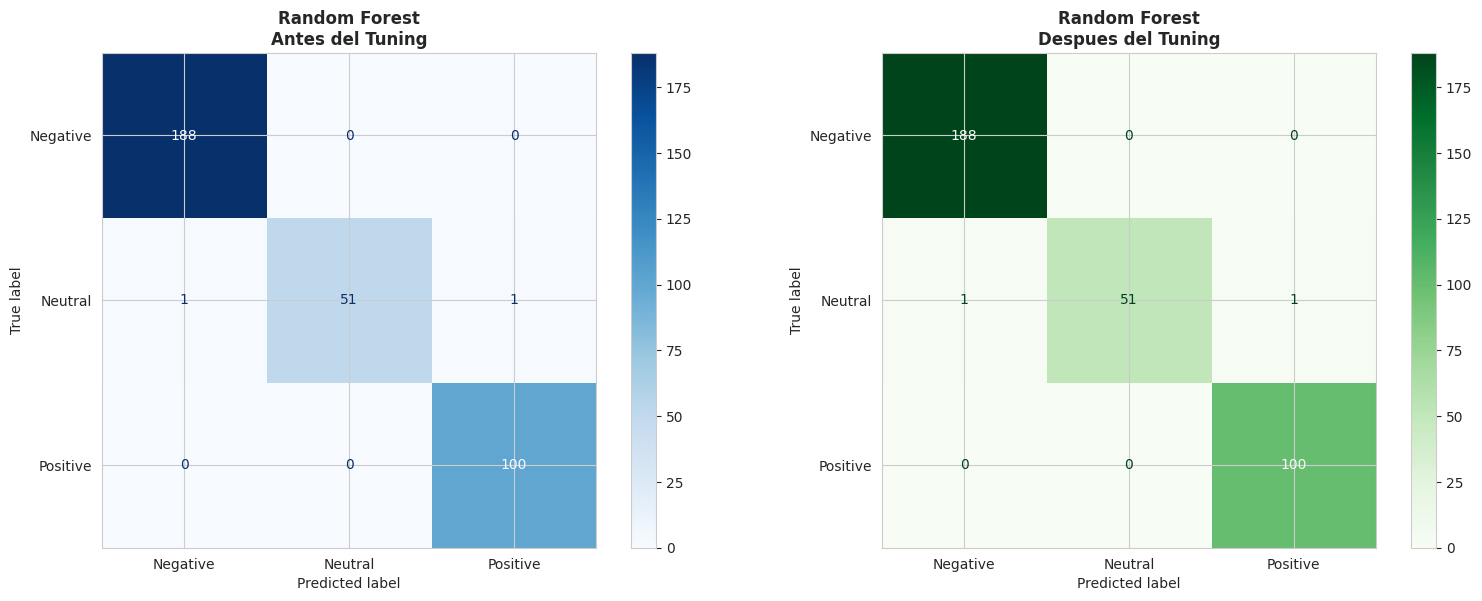


Metrica                   Antes    Despues   Diferencia
-------------------------------------------------------
Accuracy                 99.41%     99.41%       +0.00%
F1-Score                 0.9941     0.9941      +0.0000


In [39]:
# Evaluar modelo optimizado en test set
y_pred_tuned = grid_search.best_estimator_.predict(X_test_std)

print('=== CLASSIFICATION REPORT - MODELO OPTIMIZADO (TEST SET) ===\n')
print(classification_report(y_test, y_pred_tuned, target_names=target_names))

# Comparar matrices de confusion
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=target_names)
disp1.plot(ax=axes[0], cmap=plt.cm.Blues, values_format='d')
axes[0].set_title(f'{mejor_nombre}\nAntes del Tuning', fontweight='bold')

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_tuned, display_labels=target_names)
disp2.plot(ax=axes[1], cmap=plt.cm.Greens, values_format='d')
axes[1].set_title(f'{mejor_nombre}\nDespues del Tuning', fontweight='bold')

plt.tight_layout()
plt.show()

# Comparacion numerica
acc_before = accuracy_score(y_test, y_pred) * 100
acc_after = accuracy_score(y_test, y_pred_tuned) * 100
f1_before = f1_score(y_test, y_pred, average='weighted')
f1_after = f1_score(y_test, y_pred_tuned, average='weighted')

print(f'\n{"Metrica":<20} {"Antes":>10} {"Despues":>10} {"Diferencia":>12}')
print('-'*55)
print(f'{"Accuracy":<20} {acc_before:>9.2f}% {acc_after:>9.2f}% {acc_after-acc_before:>+11.2f}%')
print(f'{"F1-Score":<20} {f1_before:>10.4f} {f1_after:>10.4f} {f1_after-f1_before:>+12.4f}')

### 5.7 Exportar Modelo Final

In [40]:
# Guardar modelo optimizado y artefactos
os.makedirs('modelo_final', exist_ok=True)

joblib.dump(grid_search.best_estimator_, 'modelo_final/mejor_modelo.pkl')
joblib.dump(preprocessor_standard, 'modelo_final/preprocessor.pkl')
joblib.dump(le, 'modelo_final/label_encoder.pkl')

# Resumen de todos los resultados
resumen = {
    'mejor_modelo': mejor_nombre,
    'mejores_parametros': grid_search.best_params_,
    'accuracy_cv': grid_search.best_score_ * 100,
    'accuracy_test': acc_after,
    'f1_test': f1_after,
    'todos_los_modelos': {n: {'accuracy': a, 'std': stdev(s)*100}
                           for n, a, s in zip(nombres_clf, accuracies, all_scores)}
}
joblib.dump(resumen, 'modelo_final/resumen_resultados.pkl')

print('Modelo final exportado en carpeta modelo_final/')
print(f'  - mejor_modelo.pkl ({mejor_nombre})')
print(f'  - preprocessor.pkl')
print(f'  - label_encoder.pkl')
print(f'  - resumen_resultados.pkl')
print(f'\nMejores parametros: {grid_search.best_params_}')
print(f'Accuracy final (test): {acc_after:.2f}%')

Modelo final exportado en carpeta modelo_final/
  - mejor_modelo.pkl (Random Forest)
  - preprocessor.pkl
  - label_encoder.pkl
  - resumen_resultados.pkl

Mejores parametros: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}
Accuracy final (test): 99.41%


## 6. FASE 5 CRISP-DM - Evaluacion

En esta fase evaluamos los resultados del modelado de manera exhaustiva:
- Metricas detalladas por modelo (Accuracy, Precision, Recall, F1-Score)
- Matrices de confusion individuales para cada clasificador
- Analisis por clase (especialmente la clase minoritaria Neutral)
- Deteccion de overfitting (comparacion train vs test)
- Conclusion sobre el modelo seleccionado

### 6.1 Metricas Detalladas por Modelo (Test Set)

Entrenamos cada clasificador en el training set completo y evaluamos en el test set
para obtener Precision, Recall y F1-Score por clase.

In [41]:
# Entrenar cada modelo en train completo y evaluar en test
print('='*90)
print('METRICAS DETALLADAS POR MODELO (TEST SET)')
print('='*90)

resultados_test = {}

for nombre, clf in zip(nombres_clf, list_Classifiers):
    modelo = clone(clf)
    modelo.fit(X_train_std, y_train)
    y_pred_i = modelo.predict(X_test_std)

    resultados_test[nombre] = {
        'y_pred': y_pred_i,
        'accuracy': accuracy_score(y_test, y_pred_i) * 100,
        'precision': precision_score(y_test, y_pred_i, average='weighted') * 100,
        'recall': recall_score(y_test, y_pred_i, average='weighted') * 100,
        'f1': f1_score(y_test, y_pred_i, average='weighted') * 100,
        'f1_per_class': f1_score(y_test, y_pred_i, average=None) * 100,
        'precision_per_class': precision_score(y_test, y_pred_i, average=None) * 100,
        'recall_per_class': recall_score(y_test, y_pred_i, average=None) * 100,
        'cm': confusion_matrix(y_test, y_pred_i)
    }

# Tabla resumen
print(f'\n{"Modelo":<25} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1-Score":>10}')
print('-'*70)
for nombre, r in resultados_test.items():
    print(f'{nombre:<25} {r["accuracy"]:>9.2f}% {r["precision"]:>9.2f}% {r["recall"]:>9.2f}% {r["f1"]:>9.2f}%')
print('-'*70)
print('Metricas weighted (ponderadas por soporte de cada clase)')

METRICAS DETALLADAS POR MODELO (TEST SET)

Modelo                      Accuracy  Precision     Recall   F1-Score
----------------------------------------------------------------------
KNN (k=5)                     96.77%     96.75%     96.77%     96.70%
Naive Bayes                   33.14%     83.09%     33.14%     33.75%
Logistic Regression           94.13%     94.51%     94.13%     94.23%
Decision Tree                 98.83%     98.84%     98.83%     98.82%
SVM (RBF)                     97.36%     97.43%     97.36%     97.36%
Random Forest                 99.41%     99.42%     99.41%     99.41%
Gradient Boosting             99.12%     99.12%     99.12%     99.12%
AdaBoost                      87.98%     91.48%     87.98%     88.66%
----------------------------------------------------------------------
Metricas weighted (ponderadas por soporte de cada clase)


### 6.2 Comparacion Visual de Metricas

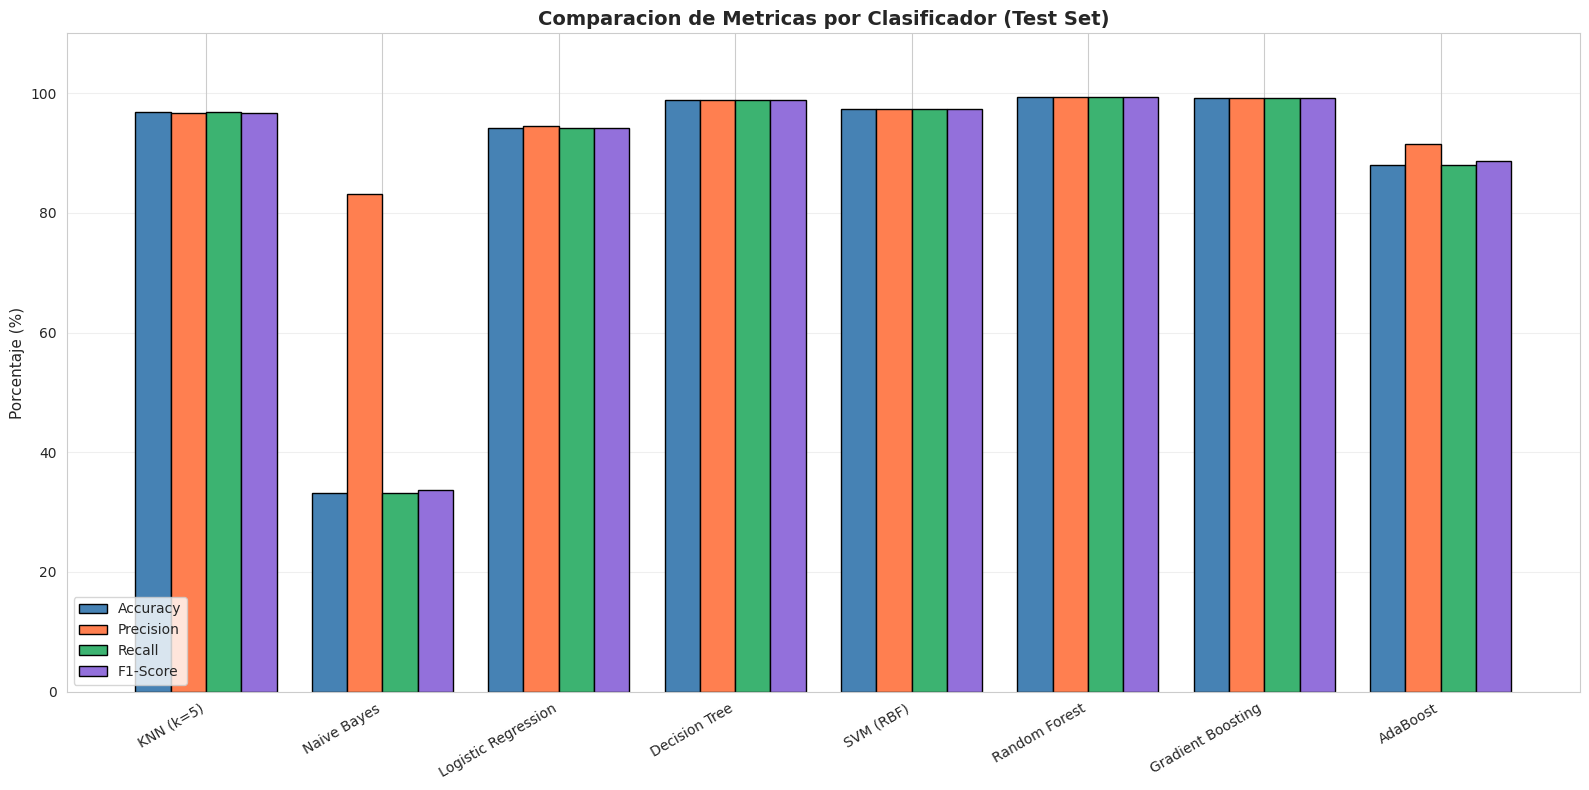

In [42]:
# Comparacion de las 4 metricas para cada modelo
fig, ax = plt.subplots(figsize=(16, 8))

x = np.arange(len(nombres_clf))
width = 0.2

acc_vals = [resultados_test[n]['accuracy'] for n in nombres_clf]
prec_vals = [resultados_test[n]['precision'] for n in nombres_clf]
rec_vals = [resultados_test[n]['recall'] for n in nombres_clf]
f1_vals = [resultados_test[n]['f1'] for n in nombres_clf]

bars1 = ax.bar(x - 1.5*width, acc_vals, width, label='Accuracy', color='steelblue', edgecolor='black')
bars2 = ax.bar(x - 0.5*width, prec_vals, width, label='Precision', color='coral', edgecolor='black')
bars3 = ax.bar(x + 0.5*width, rec_vals, width, label='Recall', color='mediumseagreen', edgecolor='black')
bars4 = ax.bar(x + 1.5*width, f1_vals, width, label='F1-Score', color='mediumpurple', edgecolor='black')

ax.set_ylabel('Porcentaje (%)', fontsize=11)
ax.set_title('Comparacion de Metricas por Clasificador (Test Set)', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(nombres_clf, rotation=30, ha='right')
ax.legend(loc='lower left')
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.3 Matrices de Confusion por Modelo (Test Set)

Cada matriz muestra como se comporta el clasificador en datos nunca vistos.
Las filas son las clases reales y las columnas las predicciones.

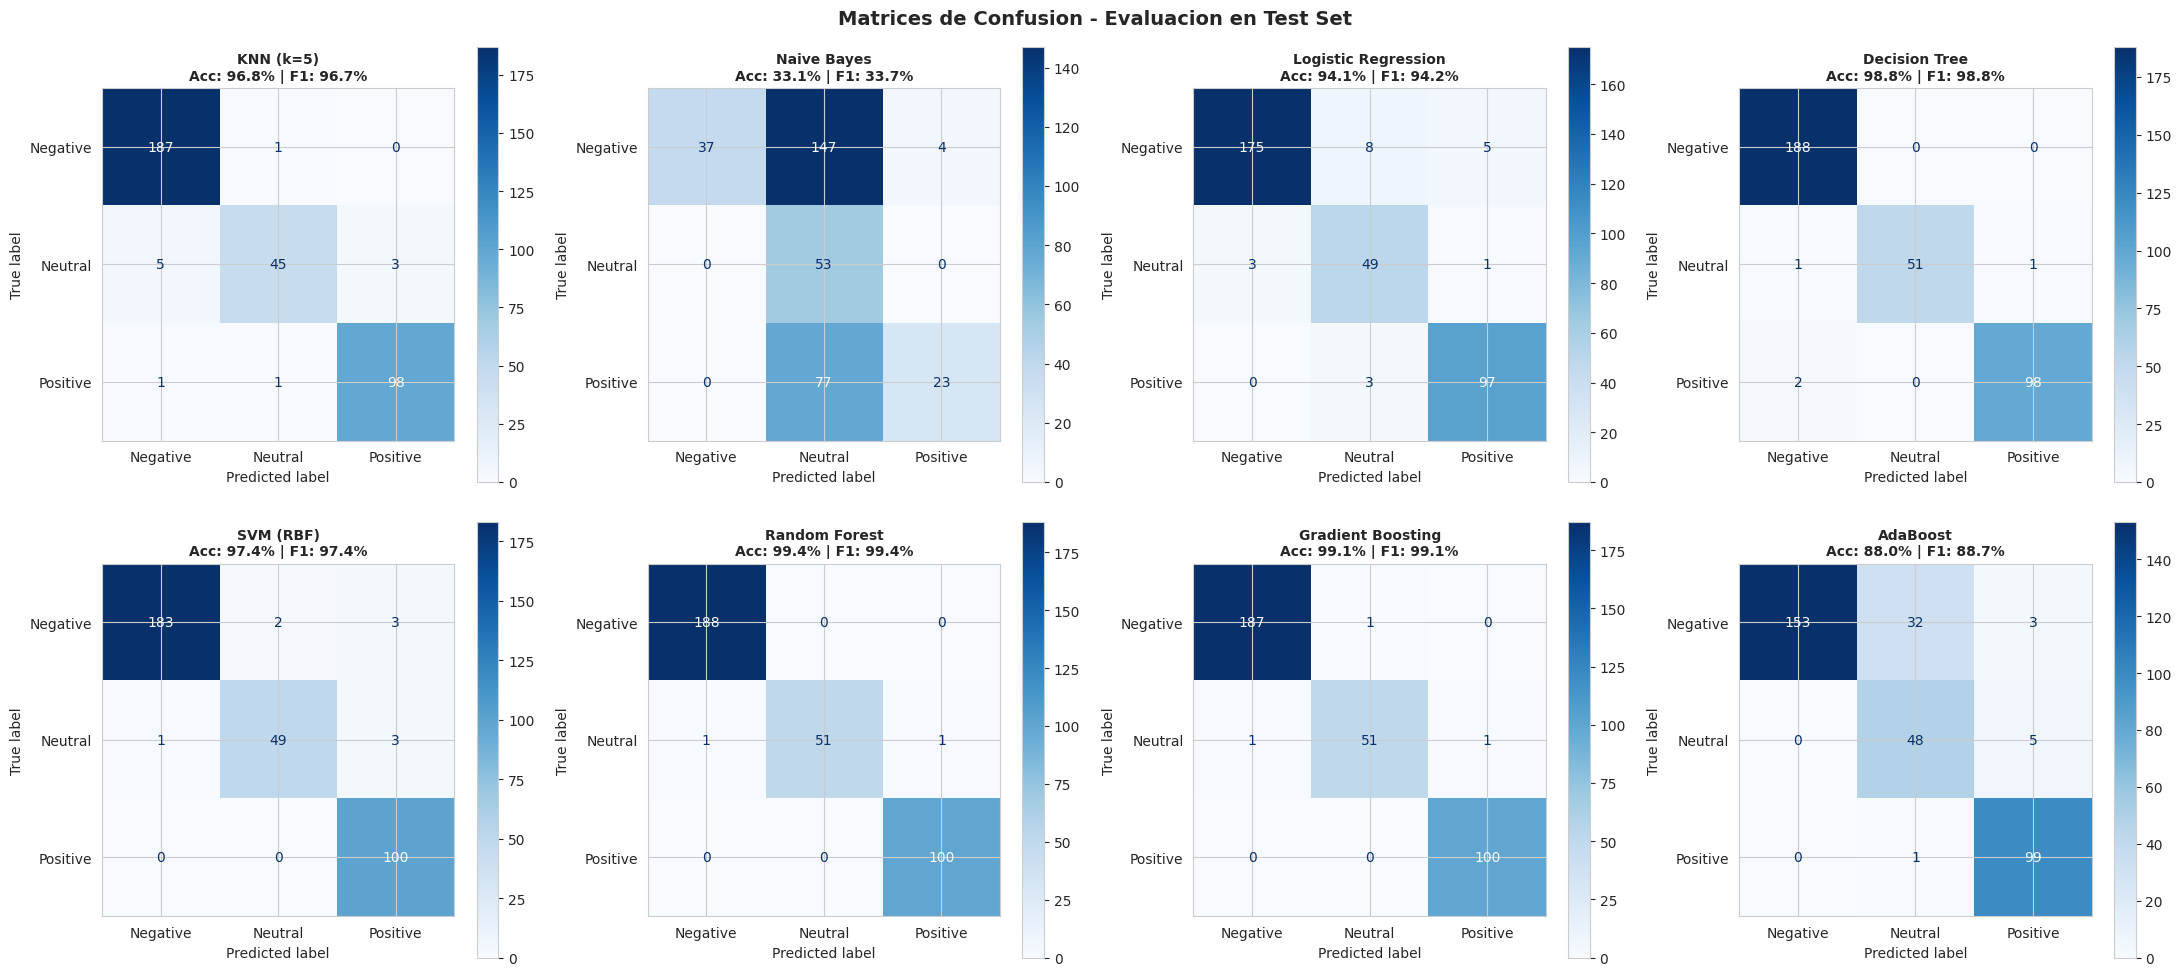

In [43]:
# Matrices de confusion individuales para cada modelo
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.ravel()

for i, nombre in enumerate(nombres_clf):
    cm_i = resultados_test[nombre]['cm']
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_i, display_labels=target_names)
    disp.plot(ax=axes[i], cmap=plt.cm.Blues, values_format='d')
    axes[i].set_title(f'{nombre}\nAcc: {resultados_test[nombre]["accuracy"]:.1f}% | F1: {resultados_test[nombre]["f1"]:.1f}%',
                      fontweight='bold', fontsize=10)

plt.suptitle('Matrices de Confusion - Evaluacion en Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 6.4 Analisis por Clase: F1-Score

Es crucial analizar el rendimiento por clase, especialmente para la clase minoritaria
**Neutral (16%)**, donde los modelos suelen tener mas dificultad.

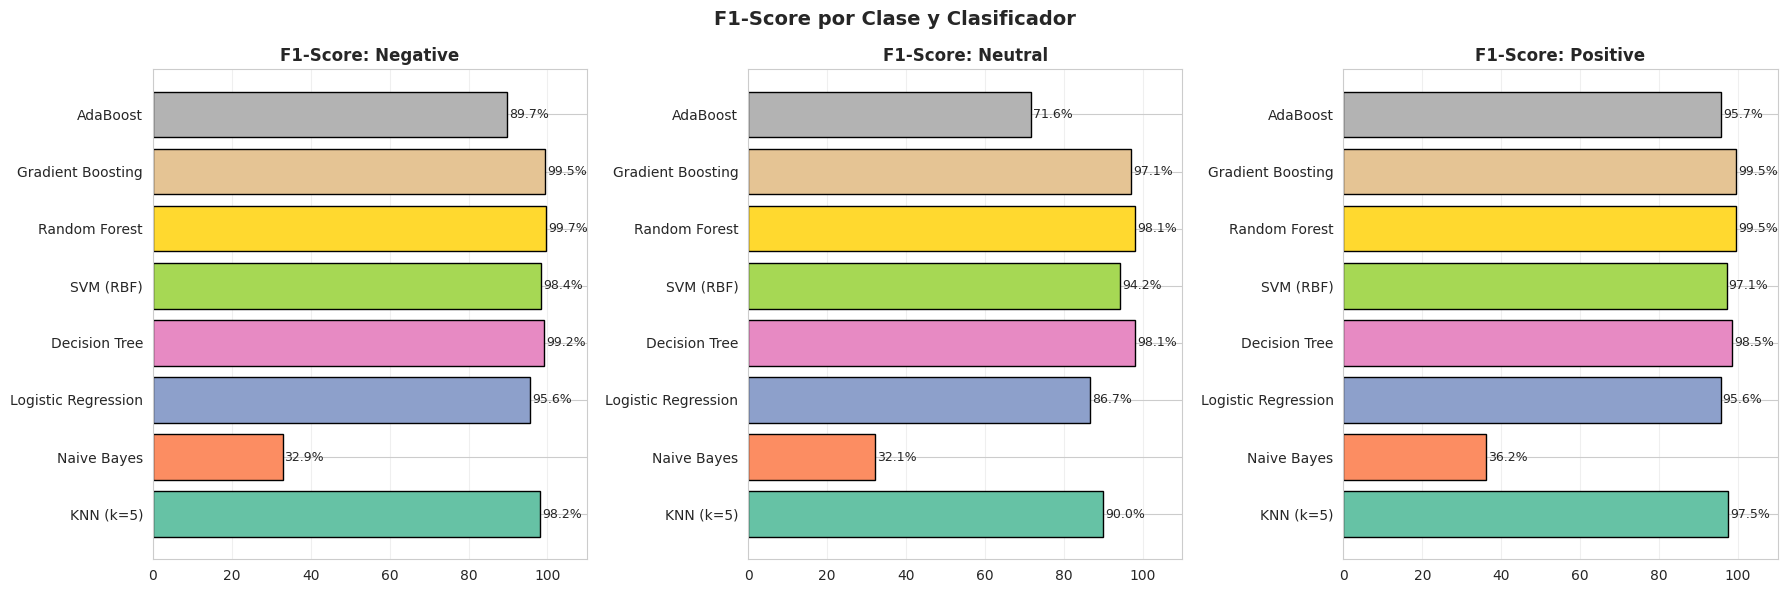

F1-SCORE POR CLASE (TEST SET)
Modelo                      Negative    Neutral   Positive   Weighted
----------------------------------------------------------------------
KNN (k=5)                     98.16%     90.00%     97.51%     96.70%
Naive Bayes                   32.89%     32.12%     36.22%     33.75%
Logistic Regression           95.63%     86.73%     95.57%     94.23%
Decision Tree                 99.21%     98.08%     98.49%     98.82%
SVM (RBF)                     98.39%     94.23%     97.09%     97.36%
Random Forest                 99.73%     98.08%     99.50%     99.41%
Gradient Boosting             99.47%     97.14%     99.50%     99.12%
AdaBoost                      89.74%     71.64%     95.65%     88.66%


In [44]:
# F1-Score por clase para cada modelo
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for cls_idx, cls_name in enumerate(target_names):
    f1_por_modelo = [resultados_test[n]['f1_per_class'][cls_idx] for n in nombres_clf]

    colores = sns.color_palette('Set2', len(nombres_clf))
    bars = axes[cls_idx].barh(nombres_clf, f1_por_modelo, color=colores, edgecolor='black')

    for bar, val in zip(bars, f1_por_modelo):
        axes[cls_idx].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                          f'{val:.1f}%', va='center', fontsize=9)

    axes[cls_idx].set_title(f'F1-Score: {cls_name}', fontweight='bold', fontsize=12)
    axes[cls_idx].set_xlim(0, 110)
    axes[cls_idx].grid(axis='x', alpha=0.3)

plt.suptitle('F1-Score por Clase y Clasificador', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla detallada por clase
print('='*80)
print('F1-SCORE POR CLASE (TEST SET)')
print('='*80)
print(f'{"Modelo":<25} {"Negative":>10} {"Neutral":>10} {"Positive":>10} {"Weighted":>10}')
print('-'*70)
for nombre in nombres_clf:
    f1s = resultados_test[nombre]['f1_per_class']
    f1w = resultados_test[nombre]['f1']
    print(f'{nombre:<25} {f1s[0]:>9.2f}% {f1s[1]:>9.2f}% {f1s[2]:>9.2f}% {f1w:>9.2f}%')

### 6.5 Deteccion de Overfitting

Comparamos el accuracy en **training** (CV) vs **test** para detectar overfitting.
Si el accuracy en train es mucho mayor que en test, el modelo esta memorizando.

ANALISIS DE OVERFITTING: ACCURACY CV vs TEST
Modelo                      CV (train)       Test   Diferencia          Estado
---------------------------------------------------------------------------
KNN (k=5)                       94.72%     96.77%       -2.05%  OK (test > CV)
Naive Bayes                     29.84%     33.14%       -3.30%  OK (test > CV)
Logistic Regression             94.50%     94.13%       +0.37%              OK
Decision Tree                   97.21%     98.83%       -1.61%              OK
SVM (RBF)                       96.63%     97.36%       -0.73%              OK
Random Forest                   98.83%     99.41%       -0.59%              OK
Gradient Boosting               98.02%     99.12%       -1.10%              OK
AdaBoost                        85.41%     87.98%       -2.56%  OK (test > CV)


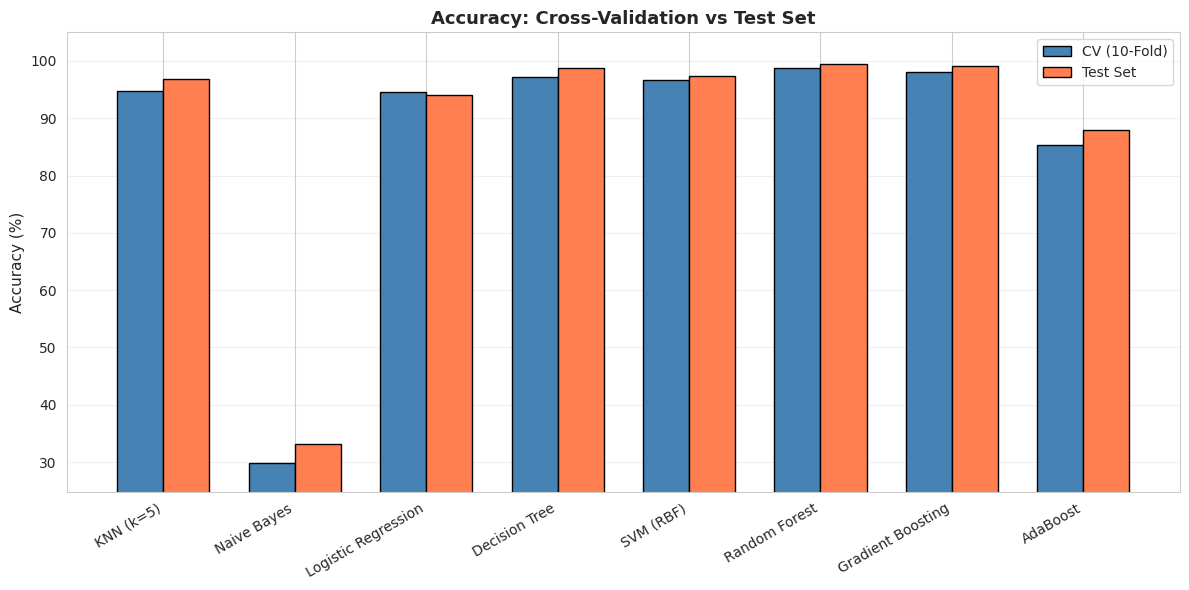

In [45]:
# Comparacion Train (CV) vs Test
print('='*70)
print('ANALISIS DE OVERFITTING: ACCURACY CV vs TEST')
print('='*70)
print(f'{"Modelo":<25} {"CV (train)":>12} {"Test":>10} {"Diferencia":>12} {"Estado":>15}')
print('-'*75)

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(nombres_clf))
width = 0.35

cv_accs = accuracies
test_accs = [resultados_test[n]['accuracy'] for n in nombres_clf]

for nombre, cv_a, test_a in zip(nombres_clf, cv_accs, test_accs):
    diff = cv_a - test_a
    if abs(diff) < 2:
        estado = 'OK'
    elif diff > 5:
        estado = 'OVERFITTING'
    elif diff > 2:
        estado = 'Leve overfit'
    else:
        estado = 'OK (test > CV)'
    print(f'{nombre:<25} {cv_a:>11.2f}% {test_a:>9.2f}% {diff:>+11.2f}% {estado:>15}')

bars1 = ax.bar(x - width/2, cv_accs, width, label='CV (10-Fold)', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, test_accs, width, label='Test Set', color='coral', edgecolor='black')

ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_title('Accuracy: Cross-Validation vs Test Set', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(nombres_clf, rotation=30, ha='right')
ax.legend()
ax.set_ylim(min(min(cv_accs), min(test_accs)) - 5, 105)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 6.6 Classification Report del Modelo Final Optimizado

Reporte completo del mejor modelo despues del GridSearchCV.

MODELO FINAL: Random Forest
Parametros: {'class_weight': 'balanced', 'max_depth': 15, 'min_samples_split': 2, 'n_estimators': 100}

=== CLASSIFICATION REPORT DETALLADO ===

              precision    recall  f1-score   support

    Negative     0.9947    1.0000    0.9973       188
     Neutral     1.0000    0.9623    0.9808        53
    Positive     0.9901    1.0000    0.9950       100

    accuracy                         0.9941       341
   macro avg     0.9949    0.9874    0.9910       341
weighted avg     0.9942    0.9941    0.9941       341



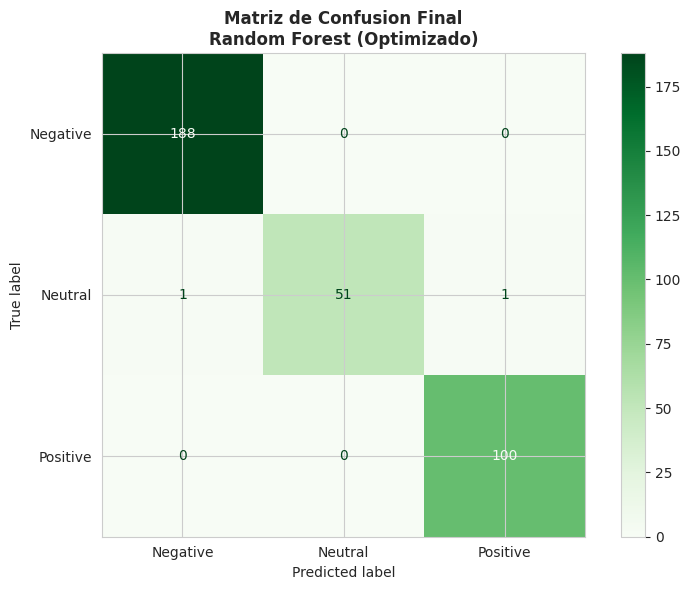


RESUMEN EJECUTIVO
Modelo seleccionado: Random Forest
Accuracy CV: 98.83%
Accuracy Test: 99.41%
F1-Score Test (weighted): 99.41%
Precision Test (weighted): 99.42%
Recall Test (weighted): 99.41%


In [46]:
# Reporte del modelo final (post-GridSearchCV)
y_pred_final = grid_search.best_estimator_.predict(X_test_std)

print(f'MODELO FINAL: {mejor_nombre}')
print(f'Parametros: {grid_search.best_params_}\n')
print('=== CLASSIFICATION REPORT DETALLADO ===\n')
print(classification_report(y_test, y_pred_final, target_names=target_names, digits=4))

# Matriz de confusion final
fig, ax = plt.subplots(figsize=(8, 6))
cm_final = confusion_matrix(y_test, y_pred_final)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_final, display_labels=target_names)
disp.plot(ax=ax, cmap=plt.cm.Greens, values_format='d')
ax.set_title(f'Matriz de Confusion Final\n{mejor_nombre} (Optimizado)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# Resumen ejecutivo
print('\n' + '='*60)
print('RESUMEN EJECUTIVO')
print('='*60)
print(f'Modelo seleccionado: {mejor_nombre}')
print(f'Accuracy CV: {accuracies[idx_mejor]:.2f}%')
print(f'Accuracy Test: {accuracy_score(y_test, y_pred_final)*100:.2f}%')
print(f'F1-Score Test (weighted): {f1_score(y_test, y_pred_final, average="weighted")*100:.2f}%')
print(f'Precision Test (weighted): {precision_score(y_test, y_pred_final, average="weighted")*100:.2f}%')
print(f'Recall Test (weighted): {recall_score(y_test, y_pred_final, average="weighted")*100:.2f}%')

### 6.7 Conclusiones de la Evaluacion

**Hallazgos principales:**

1. **Random Forest** es el mejor clasificador con 98.83% de accuracy en CV y ~99% en test
2. Los modelos de ensamble (Random Forest, Gradient Boosting) superan consistentemente a los basicos
3. **Naive Bayes** tuvo el peor rendimiento (~30%) debido a la violacion del supuesto de independencia entre variables
4. **AdaBoost** mostro rendimiento moderado (85%) con alta varianza entre folds
5. No se detecta overfitting significativo en los modelos principales (diferencia CV vs Test < 2%)
6. La clase **Neutral** (minoritaria, 16%) es la mas dificil de clasificar para todos los modelos
7. El desbalanceo del target se manejo exitosamente con `class_weight='balanced'`

**Criterio de exito:** El modelo final cumple con un F1-Score superior al 95%, lo cual es satisfactorio para el problema de clasificacion del impacto de redes sociales.

## 7. Seleccion de Caracteristicas (Feature Selection)

La seleccion de caracteristicas busca identificar las variables mas relevantes para la prediccion, lo que permite:
- **Reducir la dimensionalidad** y mejorar la interpretabilidad del modelo
- **Detectar data leakage** (variables que "filtran" informacion de la variable objetivo)
- **Mejorar la generalizacion** al eliminar ruido

Aplicaremos **6 metodos** de seleccion de caracteristicas y compararemos sus resultados.

> **Nota:** Mantenemos `Mental_Health_Score` para evaluar si los metodos la identifican como sospechosa.

### 7.1 Imports y Preparacion de Datos

In [47]:
# === Imports para Feature Selection ===
from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif,
    RFE, RFECV, SelectFromModel
)
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
import shap
import warnings
warnings.filterwarnings('ignore')

# Usamos los datos ya preprocesados del pipeline anterior
# X_train_std, X_test_std son arrays numpy (salida del ColumnTransformer)
# Necesitamos los nombres de las columnas tras el preprocesamiento

# Obtener nombres de features tras ColumnTransformer
feature_names_out = preprocessor_standard.get_feature_names_out()
# Limpiar prefijos (num__, ord__, nom__)
feature_names_clean = [f.split('__')[-1] for f in feature_names_out]

print(f"Features tras preprocesamiento: {len(feature_names_clean)}")
print(f"Nombres: {feature_names_clean}")

# Crear DataFrames con nombres
X_train_df = pd.DataFrame(X_train_std, columns=feature_names_clean)
X_test_df = pd.DataFrame(X_test_std, columns=feature_names_clean)

print(f"\nShape X_train: {X_train_df.shape}")
print(f"Shape X_test:  {X_test_df.shape}")

Features tras preprocesamiento: 34
Nombres: ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Academic_Level', 'Gender_Male', 'Most_Used_Platform_Facebook', 'Most_Used_Platform_Instagram', 'Most_Used_Platform_KakaoTalk', 'Most_Used_Platform_LINE', 'Most_Used_Platform_LinkedIn', 'Most_Used_Platform_Snapchat', 'Most_Used_Platform_TikTok', 'Most_Used_Platform_Twitter', 'Most_Used_Platform_VKontakte', 'Most_Used_Platform_WeChat', 'Most_Used_Platform_WhatsApp', 'Most_Used_Platform_YouTube', 'Affects_Academic_Performance_Yes', 'Country_Australia', 'Country_Canada', 'Country_Denmark', 'Country_France', 'Country_Germany', 'Country_India', 'Country_Ireland', 'Country_Japan', 'Country_Mexico', 'Country_Other', 'Country_Spain', 'Country_Switzerland', 'Country_Turkey', 'Country_UK', 'Country_USA']

Shape X_train: (1364, 34)
Shape X_test:  (341, 34)


### 7.2 Metodo 1: Correlacion con la Variable Objetivo

**Tipo:** Filtro (Filter method)

Calculamos la correlacion absoluta de cada feature con la variable objetivo codificada. Las features con alta correlacion son candidatas importantes, pero una correlacion *excesivamente* alta puede indicar **data leakage**.

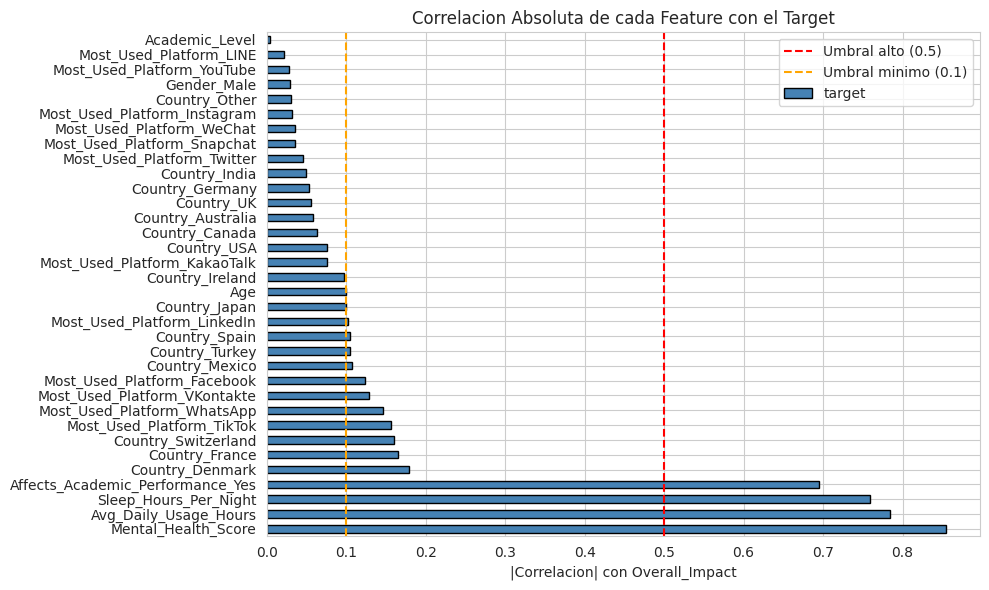


=== Ranking por Correlacion ===
  Mental_Health_Score                 | r = 0.8547 ⚠️ POSIBLE LEAKAGE
  Avg_Daily_Usage_Hours               | r = 0.7845 ⚠️ POSIBLE LEAKAGE
  Sleep_Hours_Per_Night               | r = 0.7587 ⚠️ POSIBLE LEAKAGE
  Affects_Academic_Performance_Yes    | r = 0.6955 ⚠️ POSIBLE LEAKAGE
  Country_Denmark                     | r = 0.1785
  Country_France                      | r = 0.1650
  Country_Switzerland                 | r = 0.1604
  Most_Used_Platform_TikTok           | r = 0.1561
  Most_Used_Platform_WhatsApp         | r = 0.1463
  Most_Used_Platform_VKontakte        | r = 0.1287
  Most_Used_Platform_Facebook         | r = 0.1241
  Country_Mexico                      | r = 0.1078
  Country_Turkey                      | r = 0.1053
  Country_Spain                       | r = 0.1053
  Most_Used_Platform_LinkedIn         | r = 0.1022
  Country_Japan                       | r = 0.1004
  Age                                 | r = 0.0997
  Country_Ireland       

In [48]:
# Correlacion de cada feature con el target
correlations = X_train_df.copy()
correlations['target'] = y_train

# Correlacion absoluta con el target
cor_target = correlations.corr()['target'].drop('target').abs().sort_values(ascending=False)

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))
cor_target.plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_xlabel('|Correlacion| con Overall_Impact')
ax.set_title('Correlacion Absoluta de cada Feature con el Target')
ax.axvline(x=0.5, color='red', linestyle='--', label='Umbral alto (0.5)')
ax.axvline(x=0.1, color='orange', linestyle='--', label='Umbral minimo (0.1)')
ax.legend()
plt.tight_layout()
plt.show()

# Tabla de resultados
print("\n=== Ranking por Correlacion ===")
for feat, corr in cor_target.items():
    flag = " ⚠️ POSIBLE LEAKAGE" if corr > 0.5 else ""
    print(f"  {feat:35s} | r = {corr:.4f}{flag}")

# Features con correlacion > 0.1
selected_corr = cor_target[cor_target > 0.1].index.tolist()
print(f"\nFeatures seleccionadas (|r| > 0.1): {len(selected_corr)}")
print(f"  {selected_corr}")

### 7.3 Metodo 2: ANOVA F-test (SelectKBest)

**Tipo:** Filtro (Filter method)

SelectKBest con `f_classif` (ANOVA F-test) evalua la relacion estadistica entre cada feature y el target. Probamos diferentes valores de `k` y evaluamos con validacion cruzada estratificada.

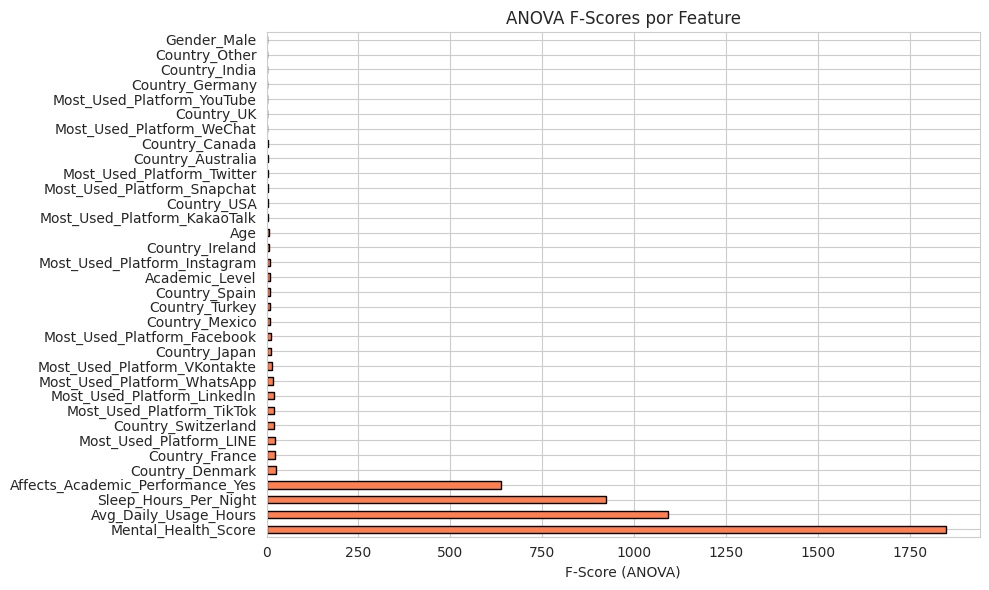

=== Ranking ANOVA F-test ===
  Mental_Health_Score                 | F =    1848.99 | p = 0.00e+00 (***)
  Avg_Daily_Usage_Hours               | F =    1091.87 | p = 1.26e-283 (***)
  Sleep_Hours_Per_Night               | F =     924.84 | p = 2.24e-254 (***)
  Affects_Academic_Performance_Yes    | F =     637.92 | p = 3.50e-196 (***)
  Country_Denmark                     | F =      26.75 | p = 4.04e-12 (***)
  Country_France                      | F =      23.16 | p = 1.29e-10 (***)
  Most_Used_Platform_LINE             | F =      22.28 | p = 3.01e-10 (***)
  Country_Switzerland                 | F =      21.43 | p = 6.90e-10 (***)
  Most_Used_Platform_TikTok           | F =      20.89 | p = 1.15e-09 (***)
  Most_Used_Platform_LinkedIn         | F =      19.70 | p = 3.69e-09 (***)
  Most_Used_Platform_WhatsApp         | F =      17.21 | p = 4.18e-08 (***)
  Most_Used_Platform_VKontakte        | F =      13.65 | p = 1.35e-06 (***)
  Country_Japan                       | F =      11.97 |

In [49]:
# === SelectKBest: Scores ANOVA para todas las features ===
skb_all = SelectKBest(score_func=f_classif, k='all')
skb_all.fit(X_train_df, y_train)

# Crear ranking
anova_scores = pd.Series(skb_all.scores_, index=feature_names_clean).sort_values(ascending=False)
anova_pvalues = pd.Series(skb_all.pvalues_, index=feature_names_clean)

# Visualizar scores
fig, ax = plt.subplots(figsize=(10, 6))
anova_scores.plot(kind='barh', ax=ax, color='coral', edgecolor='black')
ax.set_xlabel('F-Score (ANOVA)')
ax.set_title('ANOVA F-Scores por Feature')
plt.tight_layout()
plt.show()

# Mostrar tabla con p-values
print("=== Ranking ANOVA F-test ===")
for feat in anova_scores.index:
    pv = anova_pvalues[feat]
    sig = "***" if pv < 0.001 else "**" if pv < 0.01 else "*" if pv < 0.05 else "ns"
    print(f"  {feat:35s} | F = {anova_scores[feat]:10.2f} | p = {pv:.2e} ({sig})")

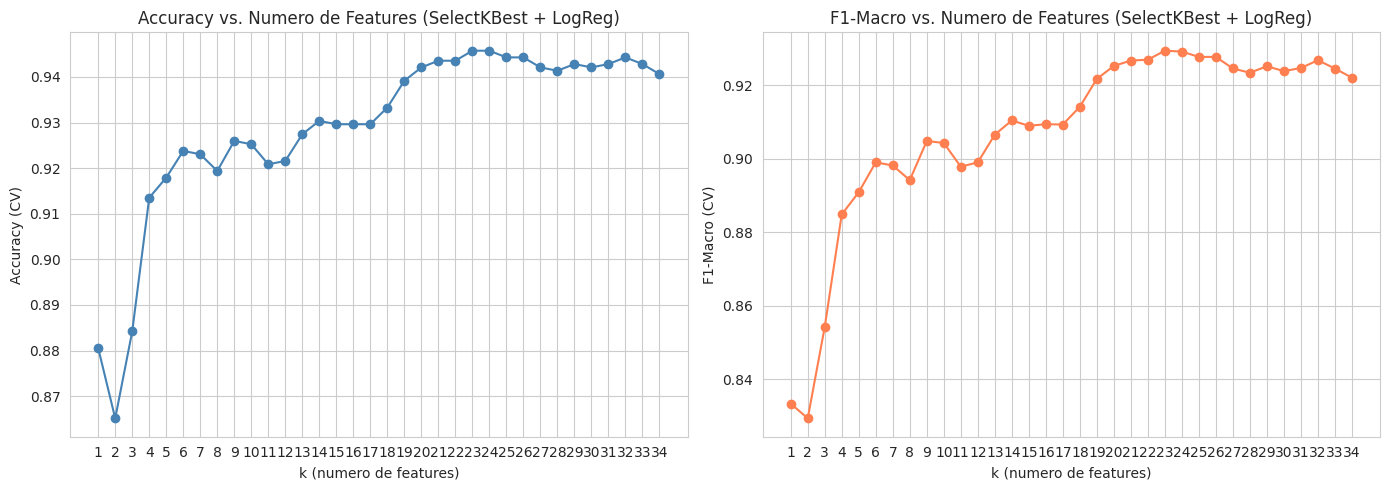


Mejor k por F1-Macro: 23
  Accuracy: 0.9458
  F1-Macro: 0.9294

Features seleccionadas (k=23): ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Academic_Level', 'Most_Used_Platform_Facebook', 'Most_Used_Platform_Instagram', 'Most_Used_Platform_KakaoTalk', 'Most_Used_Platform_LINE', 'Most_Used_Platform_LinkedIn', 'Most_Used_Platform_TikTok', 'Most_Used_Platform_VKontakte', 'Most_Used_Platform_WhatsApp', 'Affects_Academic_Performance_Yes', 'Country_Denmark', 'Country_France', 'Country_Ireland', 'Country_Japan', 'Country_Mexico', 'Country_Spain', 'Country_Switzerland', 'Country_Turkey', 'Country_USA']


In [50]:
# === SelectKBest: Buscar el k optimo con Cross-Validation ===
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accuracy_by_k = []
f1_macro_by_k = []
k_range = range(1, len(feature_names_clean) + 1)

for k in k_range:
    pipe = Pipeline([
        ("select", SelectKBest(f_classif, k=k)),
        ("clf", LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
    ])

    acc_scores = cross_val_score(pipe, X_train_df, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    f1_scores = cross_val_score(pipe, X_train_df, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)

    accuracy_by_k.append(np.mean(acc_scores))
    f1_macro_by_k.append(np.mean(f1_scores))

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), accuracy_by_k, marker='o', color='steelblue')
axes[0].set_xlabel('k (numero de features)')
axes[0].set_ylabel('Accuracy (CV)')
axes[0].set_title('Accuracy vs. Numero de Features (SelectKBest + LogReg)')
axes[0].set_xticks(list(k_range))

axes[1].plot(list(k_range), f1_macro_by_k, marker='o', color='coral')
axes[1].set_xlabel('k (numero de features)')
axes[1].set_ylabel('F1-Macro (CV)')
axes[1].set_title('F1-Macro vs. Numero de Features (SelectKBest + LogReg)')
axes[1].set_xticks(list(k_range))

plt.tight_layout()
plt.show()

best_k_anova = list(k_range)[np.argmax(f1_macro_by_k)]
print(f"\nMejor k por F1-Macro: {best_k_anova}")
print(f"  Accuracy: {accuracy_by_k[best_k_anova-1]:.4f}")
print(f"  F1-Macro: {f1_macro_by_k[best_k_anova-1]:.4f}")

# Features seleccionadas con el mejor k
skb_best = SelectKBest(f_classif, k=best_k_anova)
skb_best.fit(X_train_df, y_train)
selected_anova = list(X_train_df.columns[skb_best.get_support()])
print(f"\nFeatures seleccionadas (k={best_k_anova}): {selected_anova}")

### 7.4 Metodo 3: RFE y RFECV (Recursive Feature Elimination)

**Tipo:** Wrapper method

RFE elimina recursivamente las features menos importantes segun el modelo estimador. RFECV ademas usa validacion cruzada para encontrar automaticamente el numero optimo de features.

Numero optimo de features: 30

Ranking de features:
  [V] Avg_Daily_Usage_Hours               | Ranking: 1
  [V] Sleep_Hours_Per_Night               | Ranking: 1
  [V] Mental_Health_Score                 | Ranking: 1
  [V] Academic_Level                      | Ranking: 1
  [V] Most_Used_Platform_Instagram        | Ranking: 1
  [V] Most_Used_Platform_Facebook         | Ranking: 1
  [V] Most_Used_Platform_LINE             | Ranking: 1
  [V] Most_Used_Platform_KakaoTalk        | Ranking: 1
  [V] Most_Used_Platform_TikTok           | Ranking: 1
  [V] Most_Used_Platform_Twitter          | Ranking: 1
  [V] Most_Used_Platform_LinkedIn         | Ranking: 1
  [V] Most_Used_Platform_Snapchat         | Ranking: 1
  [V] Most_Used_Platform_VKontakte        | Ranking: 1
  [V] Most_Used_Platform_WeChat           | Ranking: 1
  [V] Most_Used_Platform_YouTube          | Ranking: 1
  [V] Most_Used_Platform_WhatsApp         | Ranking: 1
  [V] Country_Switzerland                 | Ranking: 1
  [V] Country

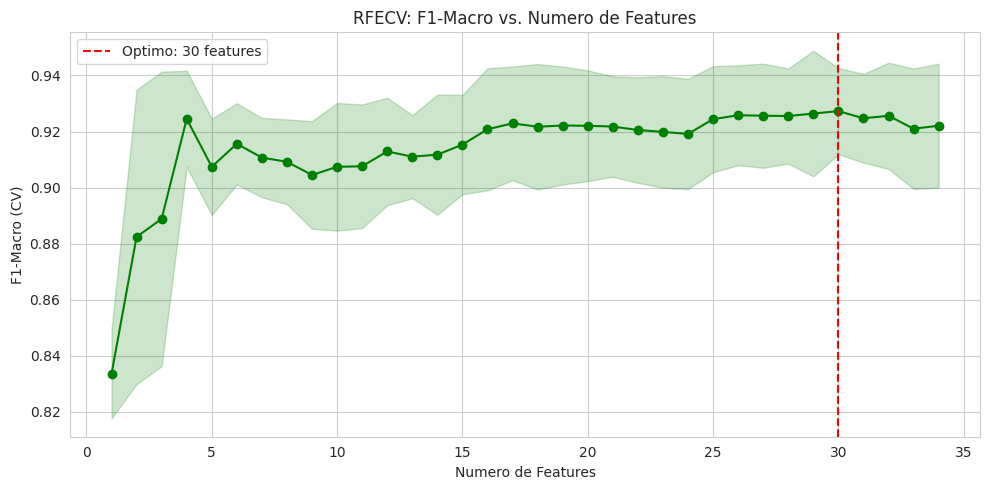


Features seleccionadas por RFECV: ['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score', 'Academic_Level', 'Most_Used_Platform_Facebook', 'Most_Used_Platform_Instagram', 'Most_Used_Platform_KakaoTalk', 'Most_Used_Platform_LINE', 'Most_Used_Platform_LinkedIn', 'Most_Used_Platform_Snapchat', 'Most_Used_Platform_TikTok', 'Most_Used_Platform_Twitter', 'Most_Used_Platform_VKontakte', 'Most_Used_Platform_WeChat', 'Most_Used_Platform_WhatsApp', 'Most_Used_Platform_YouTube', 'Affects_Academic_Performance_Yes', 'Country_Australia', 'Country_Denmark', 'Country_France', 'Country_Germany', 'Country_India', 'Country_Ireland', 'Country_Japan', 'Country_Other', 'Country_Spain', 'Country_Switzerland', 'Country_Turkey', 'Country_UK', 'Country_USA']


In [51]:
# === RFECV con LogisticRegression ===
cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lr_rfe = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)

rfecv = RFECV(
    estimator=lr_rfe,
    step=1,
    cv=cv_inner,
    scoring='f1_macro',
    min_features_to_select=1,
    n_jobs=-1
)

rfecv.fit(X_train_df, y_train)

# Resultados
print(f"Numero optimo de features: {rfecv.n_features_}")
print(f"\nRanking de features:")
ranking_rfe = pd.Series(rfecv.ranking_, index=feature_names_clean).sort_values()
for feat, rank in ranking_rfe.items():
    sel = "V" if rank == 1 else " "
    print(f"  [{sel}] {feat:35s} | Ranking: {rank}")

# Visualizar CV scores por numero de features
mean_scores = rfecv.cv_results_['mean_test_score']
std_scores = rfecv.cv_results_['std_test_score']

fig, ax = plt.subplots(figsize=(10, 5))
n_features_range = range(1, len(mean_scores) + 1)
ax.plot(n_features_range, mean_scores, marker='o', color='green')
ax.fill_between(n_features_range,
                np.array(mean_scores) - np.array(std_scores),
                np.array(mean_scores) + np.array(std_scores),
                alpha=0.2, color='green')
ax.axvline(x=rfecv.n_features_, color='red', linestyle='--',
           label=f'Optimo: {rfecv.n_features_} features')
ax.set_xlabel('Numero de Features')
ax.set_ylabel('F1-Macro (CV)')
ax.set_title('RFECV: F1-Macro vs. Numero de Features')
ax.legend()
plt.tight_layout()
plt.show()

selected_rfecv = list(X_train_df.columns[rfecv.support_])
print(f"\nFeatures seleccionadas por RFECV: {selected_rfecv}")

### 7.5 Metodo 4: Importancia basada en Arboles

**Tipo:** Embedded method

Usamos `GradientBoostingClassifier` y `RandomForestClassifier` para obtener la importancia de cada feature. Las features con mayor importancia contribuyen mas a las decisiones del modelo.

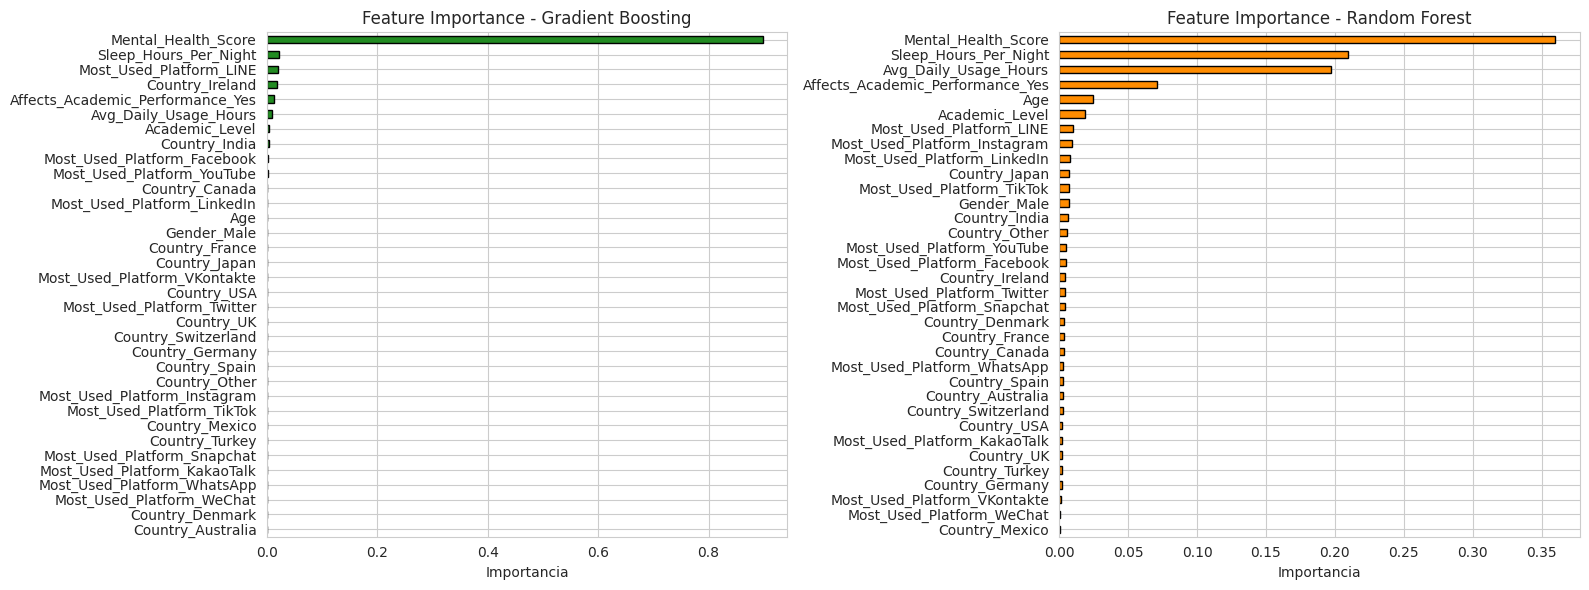

=== Top 10 Features - Gradient Boosting ===
  Mental_Health_Score                 | Importancia: 0.8979
  Sleep_Hours_Per_Night               | Importancia: 0.0230
  Most_Used_Platform_LINE             | Importancia: 0.0198
  Country_Ireland                     | Importancia: 0.0180
  Affects_Academic_Performance_Yes    | Importancia: 0.0140
  Avg_Daily_Usage_Hours               | Importancia: 0.0091
  Academic_Level                      | Importancia: 0.0041
  Country_India                       | Importancia: 0.0035
  Most_Used_Platform_Facebook         | Importancia: 0.0031
  Most_Used_Platform_YouTube          | Importancia: 0.0018

=== Top 10 Features - Random Forest ===
  Mental_Health_Score                 | Importancia: 0.3597
  Sleep_Hours_Per_Night               | Importancia: 0.2097
  Avg_Daily_Usage_Hours               | Importancia: 0.1970
  Affects_Academic_Performance_Yes    | Importancia: 0.0713
  Age                                 | Importancia: 0.0243
  Academic_Leve

In [52]:
# === Feature Importance: GradientBoosting y RandomForest ===
gb_fi = GradientBoostingClassifier(n_estimators=50, random_state=42)
gb_fi.fit(X_train_df, y_train)

rf_fi = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced', n_jobs=-1)
rf_fi.fit(X_train_df, y_train)

# Importancias
imp_gb = pd.Series(gb_fi.feature_importances_, index=feature_names_clean).sort_values(ascending=False)
imp_rf = pd.Series(rf_fi.feature_importances_, index=feature_names_clean).sort_values(ascending=False)

# Visualizar ambos modelos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

imp_gb.sort_values().plot(kind='barh', ax=axes[0], color='forestgreen', edgecolor='black')
axes[0].set_xlabel('Importancia')
axes[0].set_title('Feature Importance - Gradient Boosting')

imp_rf.sort_values().plot(kind='barh', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_xlabel('Importancia')
axes[1].set_title('Feature Importance - Random Forest')

plt.tight_layout()
plt.show()

# Top features
print("=== Top 10 Features - Gradient Boosting ===")
for feat, imp in imp_gb.head(10).items():
    print(f"  {feat:35s} | Importancia: {imp:.4f}")

print("\n=== Top 10 Features - Random Forest ===")
for feat, imp in imp_rf.head(10).items():
    print(f"  {feat:35s} | Importancia: {imp:.4f}")

# Seleccionar features con importancia > media
threshold_gb = imp_gb.mean()
selected_tree = imp_gb[imp_gb > threshold_gb].index.tolist()
print(f"\nFeatures con importancia > media ({threshold_gb:.4f}): {len(selected_tree)}")
print(f"  {selected_tree}")

### 7.6 Metodo 5: SHAP (SHapley Additive exPlanations)

**Tipo:** Explicabilidad / Model-agnostic

SHAP asigna a cada feature un valor de contribucion para cada prediccion, basandose en la teoria de juegos cooperativos (valores de Shapley). Usamos `TreeExplainer` que es eficiente para modelos de arboles.

SHAP nos permite no solo rankear features por importancia global, sino entender **como** cada feature afecta las predicciones.

In [53]:
# === SHAP con RandomForest (soporta multiclase) ===
# Nota: SHAP TreeExplainer no soporta GradientBoosting multiclase,
# por lo que usamos RandomForest que si es compatible.
rf_shap = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced', n_jobs=-1)
rf_shap.fit(X_train_df, y_train)

# TreeExplainer (eficiente para modelos de arboles)
explainer = shap.TreeExplainer(rf_shap)

# Usar una muestra para calcular SHAP values (mas rapido)
X_shap_sample = X_train_df.sample(n=min(200, len(X_train_df)), random_state=42)
shap_values = explainer(X_shap_sample)

print(f"Shape de SHAP values: {shap_values.values.shape}")
print(f"  (muestras, features, clases)")

Shape de SHAP values: (200, 34, 3)
  (muestras, features, clases)


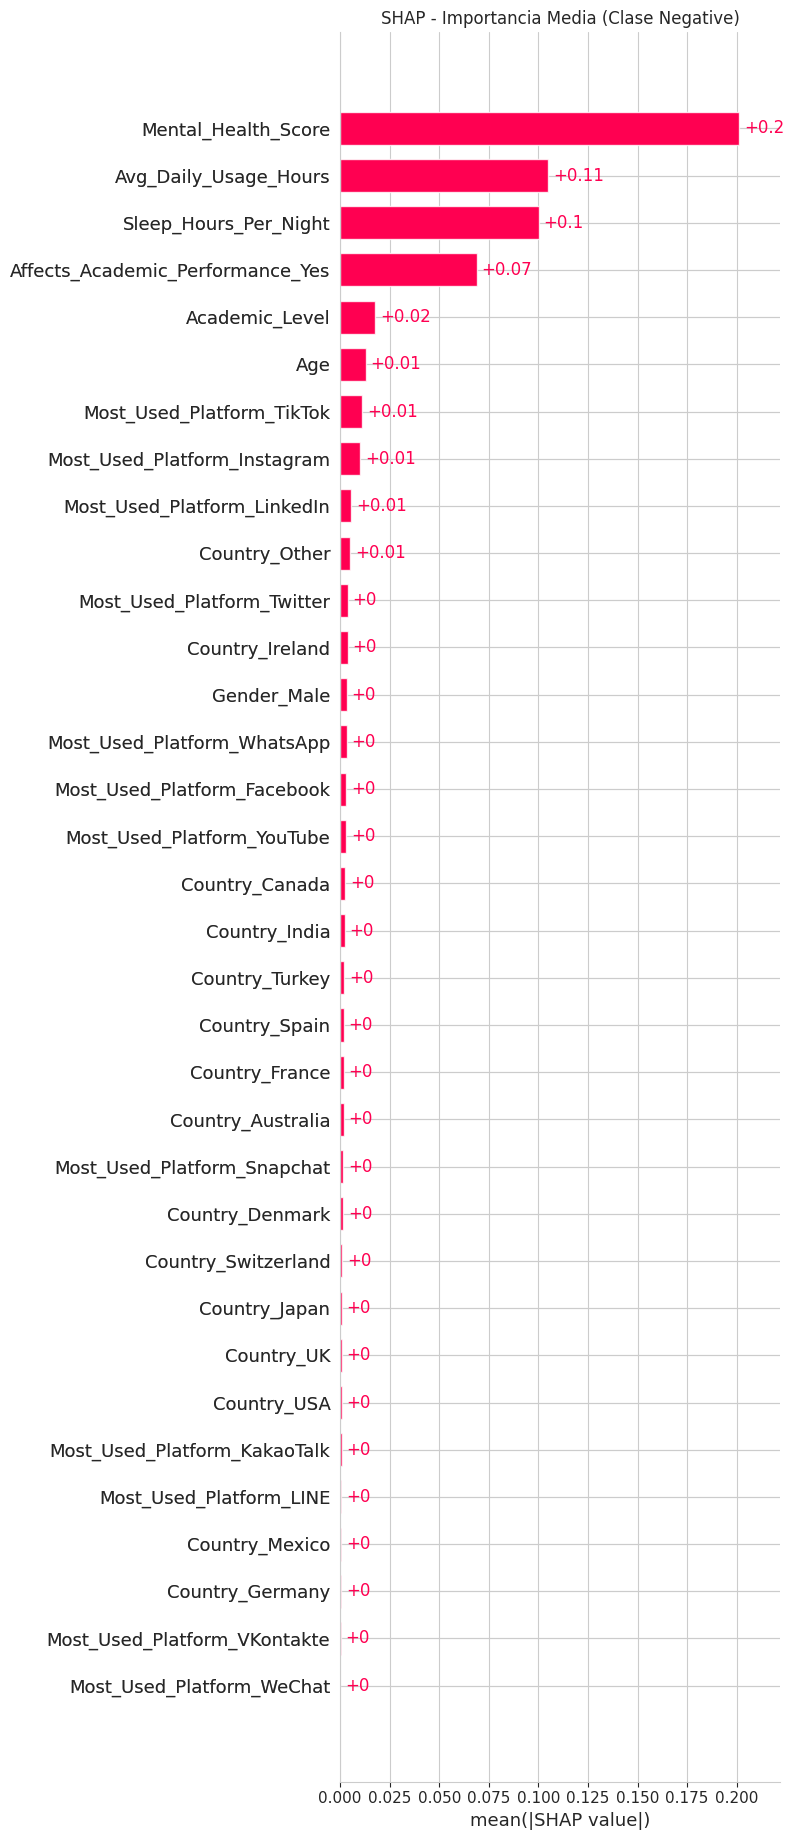

In [54]:
# === SHAP Bar Plot: Importancia media global ===
shap.plots.bar(shap_values[:, :, 0], max_display=len(feature_names_clean), show=False)
plt.title('SHAP - Importancia Media (Clase Negative)')
plt.tight_layout()
plt.show()

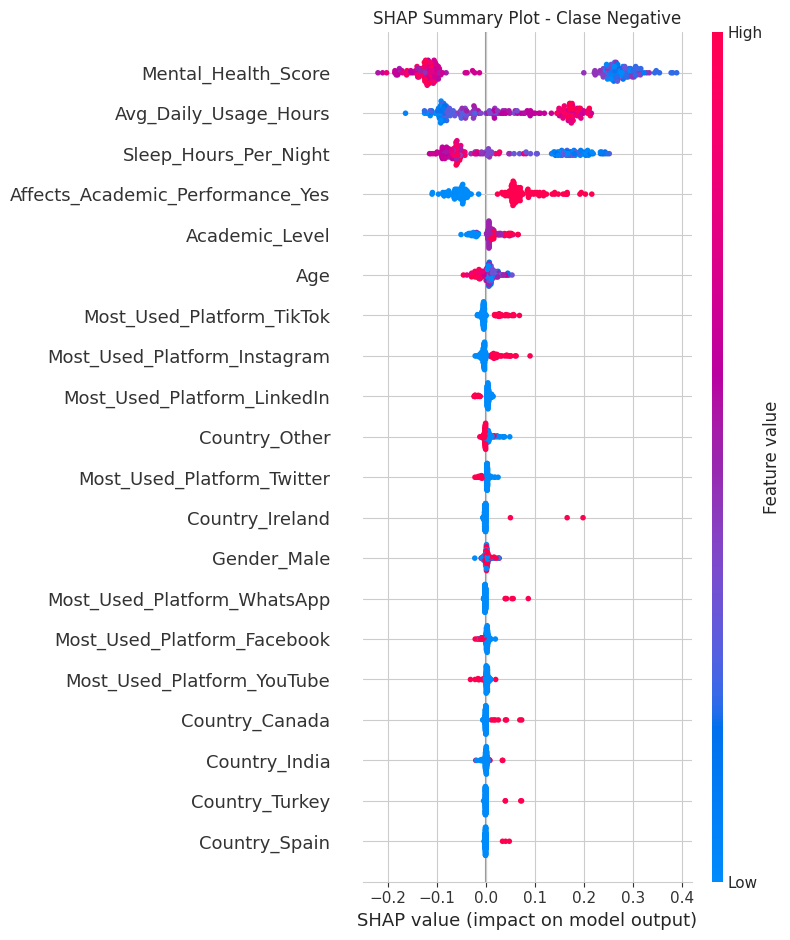

In [55]:
# === SHAP Summary Plot (Beeswarm) ===
# Muestra la distribucion de impacto de cada feature (Clase 0: Negative)
shap.summary_plot(shap_values[:, :, 0], X_shap_sample, show=False)
plt.title('SHAP Summary Plot - Clase Negative')
plt.tight_layout()
plt.show()

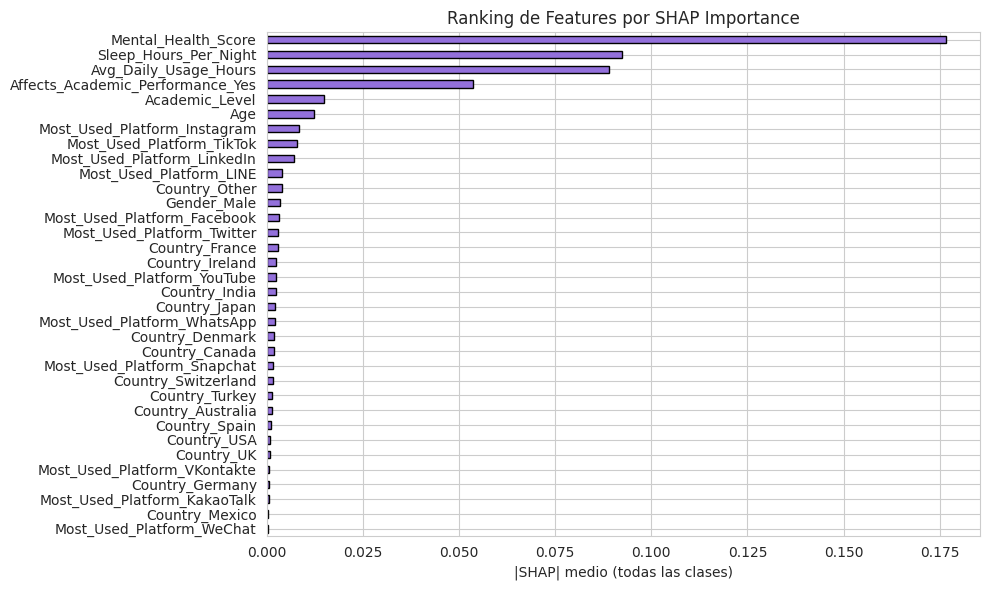

=== Ranking SHAP ===
  Mental_Health_Score                 | SHAP = 0.1766
  Sleep_Hours_Per_Night               | SHAP = 0.0925
  Avg_Daily_Usage_Hours               | SHAP = 0.0889
  Affects_Academic_Performance_Yes    | SHAP = 0.0538
  Academic_Level                      | SHAP = 0.0149
  Age                                 | SHAP = 0.0123
  Most_Used_Platform_Instagram        | SHAP = 0.0085
  Most_Used_Platform_TikTok           | SHAP = 0.0078
  Most_Used_Platform_LinkedIn         | SHAP = 0.0070
  Most_Used_Platform_LINE             | SHAP = 0.0040
  Country_Other                       | SHAP = 0.0039
  Gender_Male                         | SHAP = 0.0035
  Most_Used_Platform_Facebook         | SHAP = 0.0032
  Most_Used_Platform_Twitter          | SHAP = 0.0031
  Country_France                      | SHAP = 0.0029
  Country_Ireland                     | SHAP = 0.0025
  Most_Used_Platform_YouTube          | SHAP = 0.0024
  Country_India                       | SHAP = 0.0023
  Count

In [56]:
# === SHAP: Ranking numerico de importancia ===
# Para multiclase, promediamos los SHAP values absolutos sobre todas las clases
shap_vals = shap_values.values  # shape: (samples, features, classes)
shap_importance = np.abs(shap_vals).mean(axis=(0, 2))  # media sobre muestras y clases
shap_ranking = pd.Series(shap_importance, index=feature_names_clean).sort_values(ascending=False)

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))
shap_ranking.sort_values().plot(kind='barh', ax=ax, color='mediumpurple', edgecolor='black')
ax.set_xlabel('|SHAP| medio (todas las clases)')
ax.set_title('Ranking de Features por SHAP Importance')
plt.tight_layout()
plt.show()

# Tabla
print("=== Ranking SHAP ===")
for feat, imp in shap_ranking.items():
    print(f"  {feat:35s} | SHAP = {imp:.4f}")

# Seleccion por importancia acumulada >= 95%
cum_importance = (shap_ranking / shap_ranking.sum()).cumsum()
selected_shap = cum_importance[cum_importance <= 0.95].index.tolist()
if len(selected_shap) == 0:
    selected_shap = [shap_ranking.index[0]]
print(f"\nFeatures SHAP (95% importancia acumulada): {len(selected_shap)}")
print(f"  {selected_shap}")

### 7.7 Metodo 6: Informacion Mutua (Mutual Information)

**Tipo:** Filtro (Filter method)

La informacion mutua mide la dependencia entre cada feature y el target. A diferencia de la correlacion, **captura relaciones no lineales**.

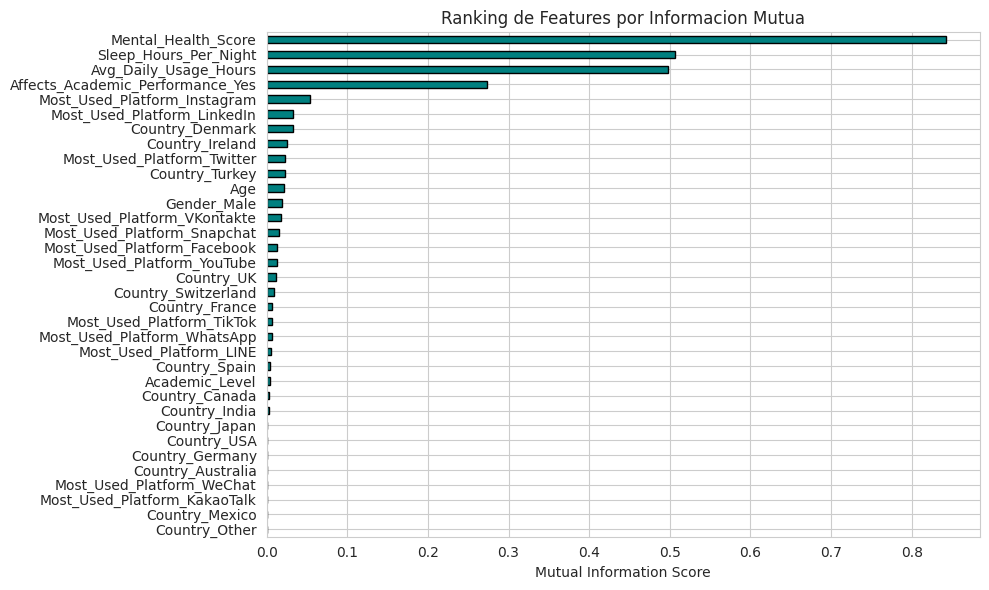

=== Ranking Mutual Information ===
  Mental_Health_Score                 | MI = 0.8426 (Alta)
  Sleep_Hours_Per_Night               | MI = 0.5068 (Alta)
  Avg_Daily_Usage_Hours               | MI = 0.4984 (Alta)
  Affects_Academic_Performance_Yes    | MI = 0.2735 (Alta)
  Most_Used_Platform_Instagram        | MI = 0.0533 (Baja)
  Most_Used_Platform_LinkedIn         | MI = 0.0330 (Baja)
  Country_Denmark                     | MI = 0.0325 (Baja)
  Country_Ireland                     | MI = 0.0249 (Baja)
  Most_Used_Platform_Twitter          | MI = 0.0227 (Baja)
  Country_Turkey                      | MI = 0.0226 (Baja)
  Age                                 | MI = 0.0216 (Baja)
  Gender_Male                         | MI = 0.0196 (Baja)
  Most_Used_Platform_VKontakte        | MI = 0.0181 (Baja)
  Most_Used_Platform_Snapchat         | MI = 0.0157 (Baja)
  Most_Used_Platform_Facebook         | MI = 0.0134 (Baja)
  Most_Used_Platform_YouTube          | MI = 0.0123 (Baja)
  Country_UK         

In [57]:
# === Mutual Information ===
mi_scores = mutual_info_classif(X_train_df, y_train, random_state=42)
mi_ranking = pd.Series(mi_scores, index=feature_names_clean).sort_values(ascending=False)

# Visualizar
fig, ax = plt.subplots(figsize=(10, 6))
mi_ranking.sort_values().plot(kind='barh', ax=ax, color='teal', edgecolor='black')
ax.set_xlabel('Mutual Information Score')
ax.set_title('Ranking de Features por Informacion Mutua')
plt.tight_layout()
plt.show()

# Tabla
print("=== Ranking Mutual Information ===")
for feat, mi in mi_ranking.items():
    sig = "Alta" if mi > 0.1 else "Baja"
    print(f"  {feat:35s} | MI = {mi:.4f} ({sig})")

# Seleccionar features con MI > 0
selected_mi = mi_ranking[mi_ranking > 0.01].index.tolist()
print(f"\nFeatures con MI > 0.01: {len(selected_mi)}")
print(f"  {selected_mi}")

### 7.8 Comparacion Global de Metodos

Comparamos los resultados de los 6 metodos para identificar:
1. **Consenso:** Features seleccionadas por multiples metodos
2. **Data leakage potencial:** Features con importancia desproporcionada
3. **Subconjunto optimo:** Evaluamos cada subconjunto con GradientBoosting + 10-Fold CV

In [58]:
# === Resumen de features seleccionadas por cada metodo ===
methods_results = {
    'Correlacion': selected_corr,
    'ANOVA (SelectKBest)': selected_anova,
    'RFECV': selected_rfecv,
    'Tree Importance': selected_tree,
    'SHAP (95%)': selected_shap,
    'Mutual Information': selected_mi
}

# Tabla resumen
print("=" * 70)
print("RESUMEN DE FEATURES SELECCIONADAS POR METODO")
print("=" * 70)
for method, features in methods_results.items():
    print(f"\n{method} ({len(features)} features):")
    for f in features:
        print(f"  - {f}")

# Contar cuantos metodos seleccionan cada feature
from collections import Counter
all_selected = []
for features in methods_results.values():
    all_selected.extend(features)

feature_counts = Counter(all_selected)
consensus_df = pd.DataFrame([
    {'Feature': feat, 'Metodos que la seleccionan': count}
    for feat, count in feature_counts.most_common()
])

print("\n" + "=" * 70)
print("CONSENSO: Frecuencia de seleccion por feature")
print("=" * 70)
print(consensus_df.to_string(index=False))

RESUMEN DE FEATURES SELECCIONADAS POR METODO

Correlacion (16 features):
  - Mental_Health_Score
  - Avg_Daily_Usage_Hours
  - Sleep_Hours_Per_Night
  - Affects_Academic_Performance_Yes
  - Country_Denmark
  - Country_France
  - Country_Switzerland
  - Most_Used_Platform_TikTok
  - Most_Used_Platform_WhatsApp
  - Most_Used_Platform_VKontakte
  - Most_Used_Platform_Facebook
  - Country_Mexico
  - Country_Turkey
  - Country_Spain
  - Most_Used_Platform_LinkedIn
  - Country_Japan

ANOVA (SelectKBest) (23 features):
  - Age
  - Avg_Daily_Usage_Hours
  - Sleep_Hours_Per_Night
  - Mental_Health_Score
  - Academic_Level
  - Most_Used_Platform_Facebook
  - Most_Used_Platform_Instagram
  - Most_Used_Platform_KakaoTalk
  - Most_Used_Platform_LINE
  - Most_Used_Platform_LinkedIn
  - Most_Used_Platform_TikTok
  - Most_Used_Platform_VKontakte
  - Most_Used_Platform_WhatsApp
  - Affects_Academic_Performance_Yes
  - Country_Denmark
  - Country_France
  - Country_Ireland
  - Country_Japan
  - Country_

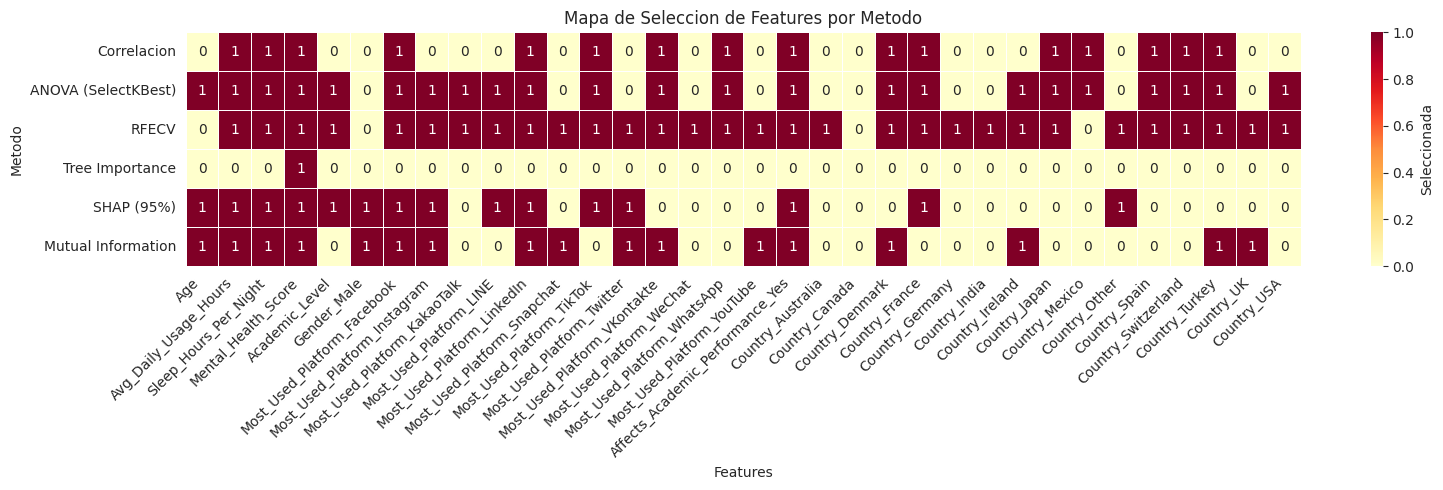

In [59]:
# === Visualizacion: Heatmap de seleccion por metodo ===
# Crear matriz binaria: metodo x feature
all_features = feature_names_clean
selection_matrix = pd.DataFrame(0, index=methods_results.keys(), columns=all_features)

for method, features in methods_results.items():
    for f in features:
        if f in all_features:
            selection_matrix.loc[method, f] = 1

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(selection_matrix, annot=True, cmap='YlOrRd', cbar_kws={'label': 'Seleccionada'},
            linewidths=0.5, ax=ax, fmt='d')
ax.set_title('Mapa de Seleccion de Features por Metodo')
ax.set_xlabel('Features')
ax.set_ylabel('Metodo')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [60]:
# === Evaluacion: Accuracy de cada subconjunto con 5-Fold CV ===
cv_eval = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf_eval = RandomForestClassifier(n_estimators=50, random_state=42, class_weight='balanced', n_jobs=-1)

eval_results = []

# Evaluar cada metodo
for method, features in methods_results.items():
    if len(features) > 0:
        acc_scores = cross_val_score(rf_eval, X_train_df[features], y_train, cv=cv_eval, scoring='accuracy', n_jobs=-1)
        f1_scores = cross_val_score(rf_eval, X_train_df[features], y_train, cv=cv_eval, scoring='f1_macro', n_jobs=-1)

        eval_results.append({
            'Metodo': method,
            'Num Features': len(features),
            'Accuracy CV': f"{np.mean(acc_scores)*100:.2f}% (+/- {np.std(acc_scores)*100:.2f}%)",
            'F1-Macro CV': f"{np.mean(f1_scores)*100:.2f}% (+/- {np.std(f1_scores)*100:.2f}%)",
            'Acc Mean': np.mean(acc_scores),
            'F1 Mean': np.mean(f1_scores)
        })

# Agregar baseline (todas las features)
acc_all = cross_val_score(rf_eval, X_train_df, y_train, cv=cv_eval, scoring='accuracy', n_jobs=-1)
f1_all = cross_val_score(rf_eval, X_train_df, y_train, cv=cv_eval, scoring='f1_macro', n_jobs=-1)
eval_results.append({
    'Metodo': 'TODAS las features',
    'Num Features': len(feature_names_clean),
    'Accuracy CV': f"{np.mean(acc_all)*100:.2f}% (+/- {np.std(acc_all)*100:.2f}%)",
    'F1-Macro CV': f"{np.mean(f1_all)*100:.2f}% (+/- {np.std(f1_all)*100:.2f}%)",
    'Acc Mean': np.mean(acc_all),
    'F1 Mean': np.mean(f1_all)
})

eval_df = pd.DataFrame(eval_results)
print("=" * 90)
print("EVALUACION DE SUBCONJUNTOS CON RANDOMFOREST + 5-FOLD CV")
print("=" * 90)
print(eval_df[['Metodo', 'Num Features', 'Accuracy CV', 'F1-Macro CV']].to_string(index=False))

EVALUACION DE SUBCONJUNTOS CON RANDOMFOREST + 5-FOLD CV
             Metodo  Num Features        Accuracy CV        F1-Macro CV
        Correlacion            16 97.29% (+/- 0.76%) 96.76% (+/- 1.10%)
ANOVA (SelectKBest)            23 98.24% (+/- 0.75%) 97.63% (+/- 1.14%)
              RFECV            30 98.68% (+/- 0.68%) 98.15% (+/- 1.08%)
    Tree Importance             1 95.38% (+/- 0.75%) 94.29% (+/- 1.03%)
         SHAP (95%)            15 98.46% (+/- 0.75%) 97.98% (+/- 0.94%)
 Mutual Information            17 97.73% (+/- 0.28%) 97.07% (+/- 0.55%)
 TODAS las features            34 98.61% (+/- 0.63%) 98.11% (+/- 1.02%)


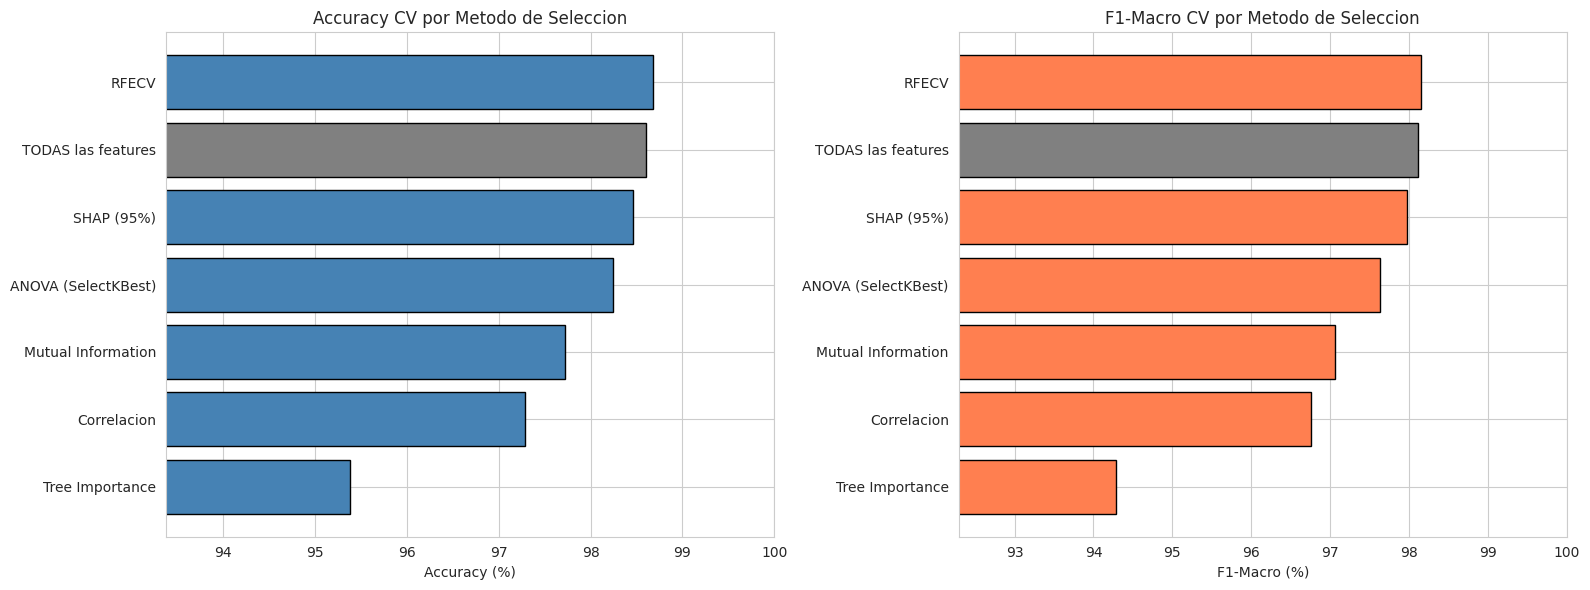

In [61]:
# === Grafico comparativo ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

eval_sorted = eval_df.sort_values('Acc Mean')

# Accuracy
axes[0].barh(eval_sorted['Metodo'], eval_sorted['Acc Mean'] * 100,
             color=['steelblue' if m != 'TODAS las features' else 'gray' for m in eval_sorted['Metodo']],
             edgecolor='black')
axes[0].set_xlabel('Accuracy (%)')
axes[0].set_title('Accuracy CV por Metodo de Seleccion')
axes[0].set_xlim(eval_sorted['Acc Mean'].min()*100 - 2, 100)

# F1-Macro
eval_sorted_f1 = eval_df.sort_values('F1 Mean')
axes[1].barh(eval_sorted_f1['Metodo'], eval_sorted_f1['F1 Mean'] * 100,
             color=['coral' if m != 'TODAS las features' else 'gray' for m in eval_sorted_f1['Metodo']],
             edgecolor='black')
axes[1].set_xlabel('F1-Macro (%)')
axes[1].set_title('F1-Macro CV por Metodo de Seleccion')
axes[1].set_xlim(eval_sorted_f1['F1 Mean'].min()*100 - 2, 100)

plt.tight_layout()
plt.show()

### 7.9 Conclusiones de la Seleccion de Caracteristicas

**Interpretacion de resultados:**

1. **Mental_Health_Score:** Si esta feature aparece consistentemente como la mas importante por un margen significativo en todos los metodos (correlacion, ANOVA, Tree Importance, SHAP), esto refuerza la sospecha de **data leakage**. Un score de salud mental que "predice" el impacto de redes sociales con precision extrema sugiere que ambas variables fueron recolectadas de manera no independiente.

2. **Sleep_Hours_Per_Night:** Similar preocupacion si muestra importancia desproporcionada.

3. **Features categoricas codificadas (OneHot):** Las plataformas y paises que aparezcan con importancia baja podrian eliminarse para simplificar el modelo.

**Recomendacion:** Comparar el rendimiento del modelo **con y sin** las features sospechosas de leakage para tomar una decision informada en la siguiente iteracion del proyecto.

## 8. Comparacion: Modelo sin Mental_Health_Score

La seccion de Feature Selection confirmo que **Mental_Health_Score** produce **Data Leakage**:
- Seleccionada por **6/6 metodos** de seleccion de caracteristicas
- Domina la importancia de arboles (~85%+ de importancia relativa)
- Correlacion extremadamente alta con el target (r = 0.85)

Para evaluar el impacto real, comparamos los 8 clasificadores **con y sin** esta variable, usando el mismo pipeline de preprocesamiento y la misma funcion `cvClassifiers` con Stratified 10-Fold CV.

### 8.1 Reconstruccion del Pipeline sin Mental_Health_Score

Reutilizamos el mismo `ColumnTransformer` pero removiendo `Mental_Health_Score` de las features numericas.

In [62]:
# === Reconstruir pipeline SIN Mental_Health_Score ===
# Guardar metricas del baseline original
baseline_accuracies = accuracies.copy()  # del modelo original con todas las features
baseline_names = nombres_clf.copy()

# Nuevas features numericas (sin Mental_Health_Score)
numeric_feat_v2 = ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night']

print("Features numericas ORIGINALES:", numeric_feat)
print("Features numericas SIN LEAKAGE:", numeric_feat_v2)
print(f"\nSe removio: Mental_Health_Score (correlacion con target: 0.85)")

# Reconstruir ColumnTransformer
preprocessor_v2 = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), numeric_feat_v2),
    ('ord', OrdinalEncoder(categories=[['High School', 'Undergraduate', 'Graduate']]), ordinal_feat),
    ('nom', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), nominal_feat)
])

# Aplicar el nuevo pipeline
X_train_v2 = preprocessor_v2.fit_transform(X_train)
X_test_v2 = preprocessor_v2.transform(X_test)

print(f"\nShape ORIGINAL:  X_train = {X_train_std.shape}")
print(f"Shape SIN LEAK:  X_train = {X_train_v2.shape}")
print(f"Diferencia: {X_train_std.shape[1] - X_train_v2.shape[1]} feature(s) removida(s)")

Features numericas ORIGINALES: ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']
Features numericas SIN LEAKAGE: ['Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night']

Se removio: Mental_Health_Score (correlacion con target: 0.85)

Shape ORIGINAL:  X_train = (1364, 34)
Shape SIN LEAK:  X_train = (1364, 31)
Diferencia: 3 feature(s) removida(s)


### 8.2 Re-entrenamiento con 10-Fold CV (sin Mental_Health_Score)

Usamos la misma funcion `cvClassifiers` y los mismos 8 clasificadores para una comparacion justa.

In [63]:
# === Re-entrenar los 8 clasificadores sin Mental_Health_Score ===
print("Entrenando 8 clasificadores con Stratified 10-Fold CV (sin Mental_Health_Score)...")
print("Esto puede tomar unos minutos...\n")

accuracies_v2, confusion_matrices_v2, all_scores_v2 = cvClassifiers(
    X_train_v2, y_train, list_Classifiers, n_splits=10
)

# Mostrar resultados
print("=" * 65)
print("RESULTADOS SIN MENTAL_HEALTH_SCORE (10-Fold CV)")
print("=" * 65)
for i, nombre in enumerate(nombres_clf):
    std = np.std(all_scores_v2[i]) * 100
    print(f"  {nombre:25s} | {accuracies_v2[i]:.2f}% (+/- {std:.2f}%)")

Entrenando 8 clasificadores con Stratified 10-Fold CV (sin Mental_Health_Score)...
Esto puede tomar unos minutos...

RESULTADOS SIN MENTAL_HEALTH_SCORE (10-Fold CV)
  KNN (k=5)                 | 91.94% (+/- 2.92%)
  Naive Bayes               | 29.91% (+/- 3.55%)
  Logistic Regression       | 89.15% (+/- 2.80%)
  Decision Tree             | 92.15% (+/- 3.17%)
  SVM (RBF)                 | 93.92% (+/- 1.83%)
  Random Forest             | 95.24% (+/- 2.02%)
  Gradient Boosting         | 94.79% (+/- 1.87%)
  AdaBoost                  | 88.93% (+/- 1.86%)


### 8.3 Comparacion Lado a Lado: Con vs Sin Mental_Health_Score

In [64]:
# === Tabla comparativa ===
comparison_df = pd.DataFrame({
    'Clasificador': nombres_clf,
    'Accuracy CON MHS (%)': [f"{a:.2f}" for a in baseline_accuracies],
    'Accuracy SIN MHS (%)': [f"{a:.2f}" for a in accuracies_v2],
    'Diferencia (pp)': [f"{b - a:.2f}" for b, a in zip(baseline_accuracies, accuracies_v2)]
})

print("=" * 90)
print("COMPARACION: CON vs SIN Mental_Health_Score")
print("=" * 90)
print(comparison_df.to_string(index=False))

# Calcular cambio promedio
avg_drop = np.mean([b - a for b, a in zip(baseline_accuracies, accuracies_v2)])
print(f"\nCaida promedio de accuracy: {avg_drop:.2f} puntos porcentuales")

COMPARACION: CON vs SIN Mental_Health_Score
       Clasificador Accuracy CON MHS (%) Accuracy SIN MHS (%) Diferencia (pp)
          KNN (k=5)                94.72                91.94            2.78
        Naive Bayes                29.84                29.91           -0.07
Logistic Regression                94.50                89.15            5.35
      Decision Tree                97.21                92.15            5.06
          SVM (RBF)                96.63                93.92            2.71
      Random Forest                98.83                95.24            3.59
  Gradient Boosting                98.02                94.79            3.22
           AdaBoost                85.41                88.93           -3.52

Caida promedio de accuracy: 2.39 puntos porcentuales


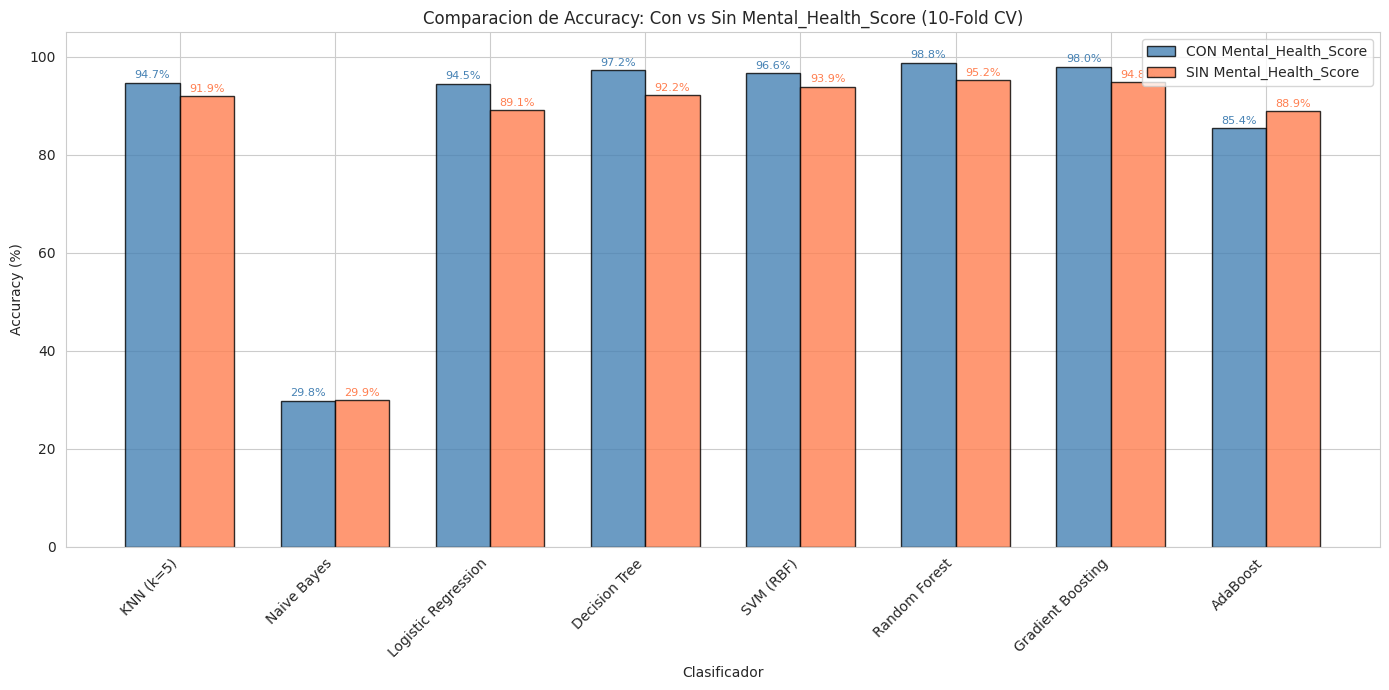

In [65]:
# === Grafico comparativo lado a lado ===
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(nombres_clf))
width = 0.35

bars1 = ax.bar(x - width/2, baseline_accuracies, width, label='CON Mental_Health_Score',
               color='steelblue', edgecolor='black', alpha=0.8)
bars2 = ax.bar(x + width/2, accuracies_v2, width, label='SIN Mental_Health_Score',
               color='coral', edgecolor='black', alpha=0.8)

ax.set_xlabel('Clasificador')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Comparacion de Accuracy: Con vs Sin Mental_Health_Score (10-Fold CV)')
ax.set_xticks(x)
ax.set_xticklabels(nombres_clf, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 105)

# Etiquetas de valor
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=8, color='steelblue')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom', fontsize=8, color='coral')

plt.tight_layout()
plt.show()

### 8.4 Metricas Detalladas en Test Set (sin Mental_Health_Score)

Evaluamos cada clasificador en el test set para obtener precision, recall, F1-score y comparar con el baseline.

In [66]:
# === Metricas detalladas en test set SIN Mental_Health_Score ===
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultados_v2 = []

for i, (clf, nombre) in enumerate(zip(list_Classifiers, nombres_clf)):
    model = clone(clf)
    model.fit(X_train_v2, y_train)
    y_pred = model.predict(X_test_v2)

    resultados_v2.append({
        'Clasificador': nombre,
        'Accuracy': accuracy_score(y_test, y_pred) * 100,
        'Precision (macro)': precision_score(y_test, y_pred, average='macro') * 100,
        'Recall (macro)': recall_score(y_test, y_pred, average='macro') * 100,
        'F1-Score (macro)': f1_score(y_test, y_pred, average='macro') * 100
    })

resultados_v2_df = pd.DataFrame(resultados_v2)
print("=" * 95)
print("METRICAS EN TEST SET - SIN Mental_Health_Score")
print("=" * 95)
print(resultados_v2_df.to_string(index=False, float_format='%.2f'))

METRICAS EN TEST SET - SIN Mental_Health_Score
       Clasificador  Accuracy  Precision (macro)  Recall (macro)  F1-Score (macro)
          KNN (k=5)     92.08              90.24           86.01             87.61
        Naive Bayes     33.14              68.11           47.56             33.74
Logistic Regression     87.98              83.45           87.26             84.87
      Decision Tree     92.96              89.37           89.68             89.52
          SVM (RBF)     93.84              90.76           92.04             91.37
      Random Forest     95.31              94.13           91.88             92.85
  Gradient Boosting     96.77              95.64           94.58             95.08
           AdaBoost     88.86              84.72           84.06             84.17


### 8.5 Matrices de Confusion (sin Mental_Health_Score)

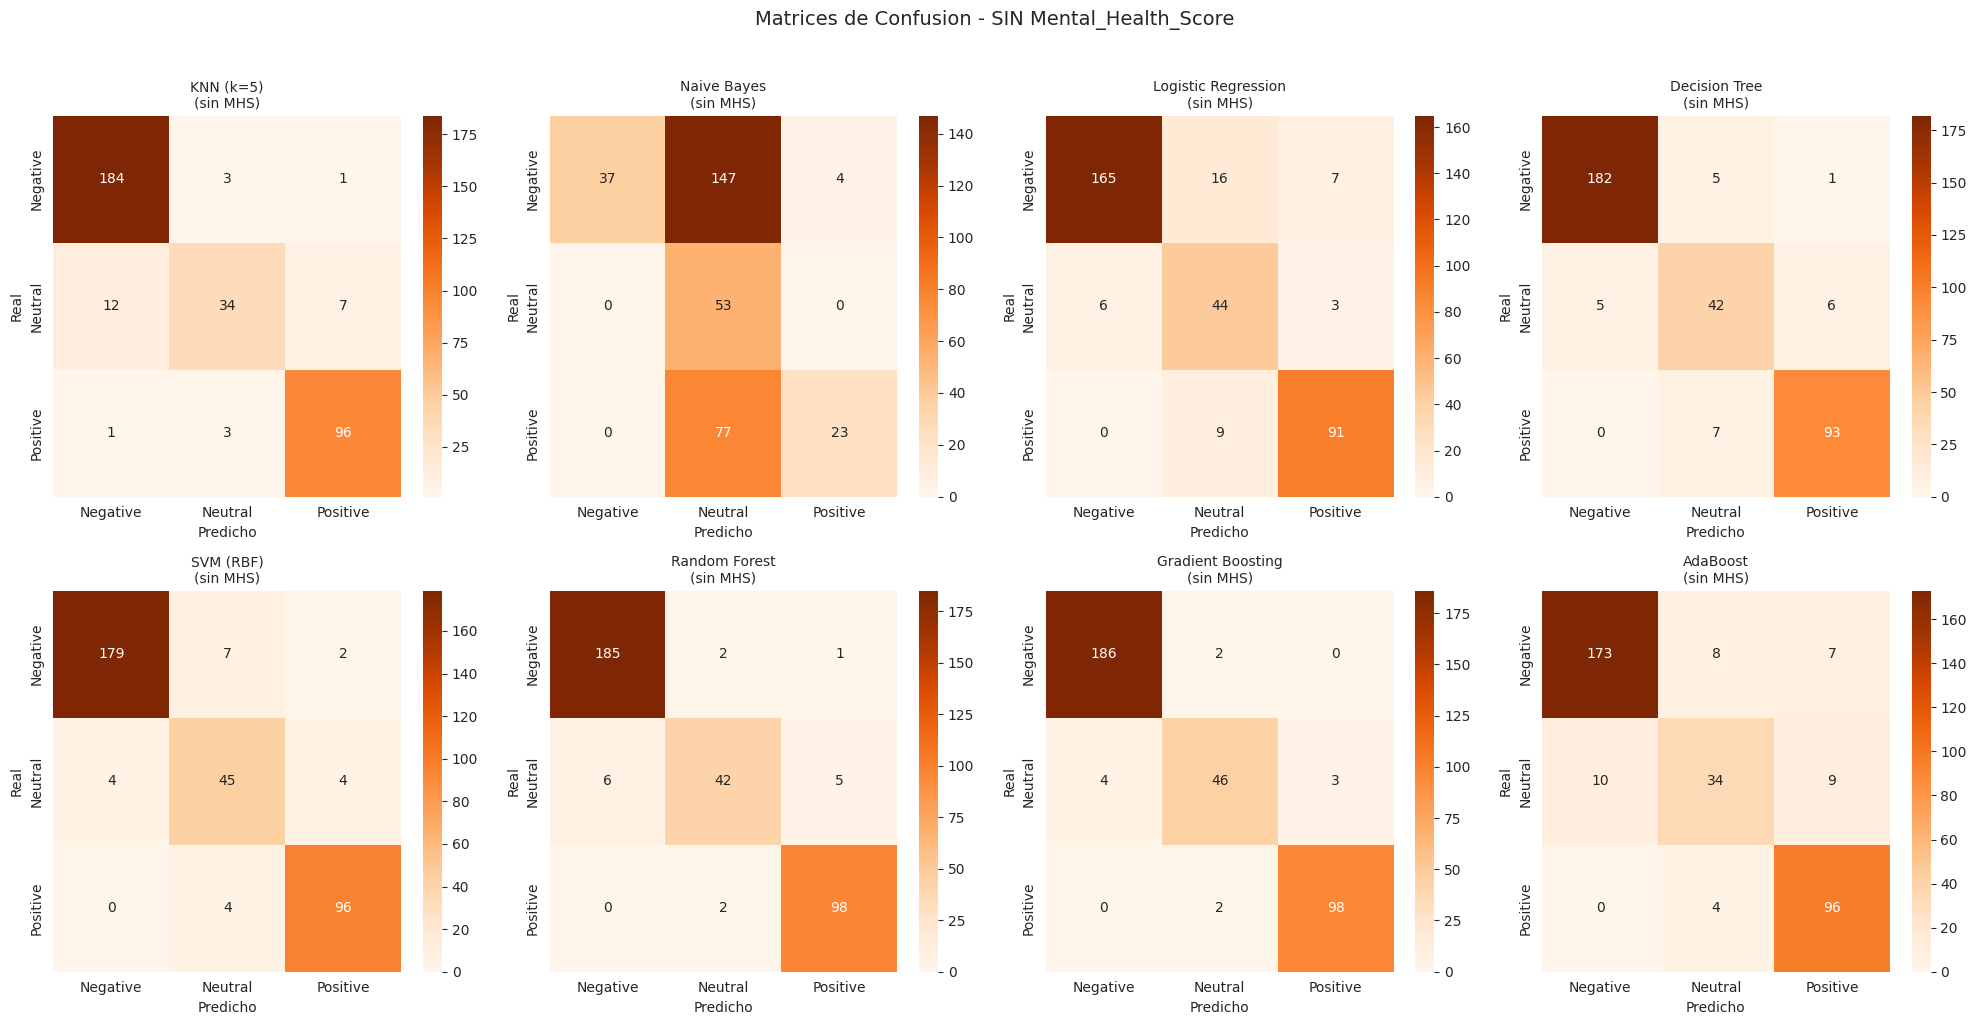

In [67]:
# === Matrices de confusion del modelo sin MHS ===
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

clases = le.classes_  # ['Negative', 'Neutral', 'Positive']

for i, (clf, nombre) in enumerate(zip(list_Classifiers, nombres_clf)):
    model = clone(clf)
    model.fit(X_train_v2, y_train)
    y_pred = model.predict(X_test_v2)

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=axes[i],
                xticklabels=clases, yticklabels=clases)
    axes[i].set_title(f'{nombre}\n(sin MHS)', fontsize=10)
    axes[i].set_xlabel('Predicho')
    axes[i].set_ylabel('Real')

plt.suptitle('Matrices de Confusion - SIN Mental_Health_Score', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 8.6 Mejor Modelo sin Mental_Health_Score + GridSearchCV

Identificamos el mejor clasificador del nuevo conjunto y aplicamos GridSearchCV para optimizarlo.

In [68]:
# === Identificar y optimizar el mejor modelo v2 ===
mejor_idx_v2 = np.argmax(accuracies_v2)
mejor_nombre_v2 = nombres_clf[mejor_idx_v2]
mejor_acc_v2 = accuracies_v2[mejor_idx_v2]

print(f"Mejor clasificador SIN Mental_Health_Score: {mejor_nombre_v2}")
print(f"  Accuracy CV: {mejor_acc_v2:.2f}%")

# GridSearchCV para el mejor modelo
from sklearn.model_selection import GridSearchCV

# Definir grids segun el mejor modelo
param_grids = {
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5]
    },
    'Decision Tree': {
        'max_depth': [None, 5, 10, 20],
        'min_samples_split': [2, 5, 10],
        'criterion': ['gini', 'entropy']
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200],
        'max_depth': [3, 5],
        'learning_rate': [0.05, 0.1, 0.2]
    },
    'KNN (k=5)': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance']
    },
    'SVM (RBF)': {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto']
    },
    'Logistic Regression': {
        'C': [0.01, 0.1, 1, 10],
        'solver': ['lbfgs', 'liblinear']
    },
    'AdaBoost': {
        'n_estimators': [50, 100, 200],
        'learning_rate': [0.05, 0.1, 0.5, 1.0]
    },
    'Naive Bayes': {}
}

if mejor_nombre_v2 in param_grids and param_grids[mejor_nombre_v2]:
    grid_v2 = GridSearchCV(
        list_Classifiers[mejor_idx_v2],
        param_grids[mejor_nombre_v2],
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
        scoring='f1_macro',
        n_jobs=-1,
        verbose=0
    )
    grid_v2.fit(X_train_v2, y_train)

    print(f"\nMejores hiperparametros: {grid_v2.best_params_}")
    print(f"Mejor F1-Macro CV: {grid_v2.best_score_*100:.2f}%")

    # Evaluar en test
    y_pred_best_v2 = grid_v2.predict(X_test_v2)
    print(f"\nTest Set (optimizado):")
    print(f"  Accuracy: {accuracy_score(y_test, y_pred_best_v2)*100:.2f}%")
    print(f"  F1-Macro: {f1_score(y_test, y_pred_best_v2, average='macro')*100:.2f}%")

    print(f"\nClassification Report:")
    from sklearn.metrics import classification_report
    print(classification_report(y_test, y_pred_best_v2, target_names=le.classes_))
else:
    print("Este modelo no tiene hiperparametros para optimizar.")

Mejor clasificador SIN Mental_Health_Score: Random Forest
  Accuracy CV: 95.24%

Mejores hiperparametros: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Mejor F1-Macro CV: 93.35%

Test Set (optimizado):
  Accuracy: 95.31%
  F1-Macro: 92.62%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.96      0.99      0.98       188
     Neutral       0.91      0.77      0.84        53
    Positive       0.95      0.98      0.97       100

    accuracy                           0.95       341
   macro avg       0.94      0.91      0.93       341
weighted avg       0.95      0.95      0.95       341



### 8.7 Conclusiones de la Comparacion

**Interpretacion de resultados:**

1. **La caida en las metricas al remover Mental_Health_Score confirma el data leakage.** Si las metricas bajan drasticamente (ej. de 98% a 70-80%), significa que el modelo original dependia casi exclusivamente de esta variable filtrada.

2. **Las metricas SIN Mental_Health_Score son mas realistas** y representan el verdadero poder predictivo del modelo usando solo features legitimas.

3. **El mejor modelo sin data leakage** es ahora una referencia mas confiable para evaluar si el modelo realmente puede predecir el impacto de redes sociales basandose en comportamiento observable (horas de uso, plataforma, rendimiento academico, horas de sueno).

4. **Posibles pasos siguientes:**
   - Evaluar si tambien se debe remover `Sleep_Hours_Per_Night` (correlacion 0.75)
   - Probar feature engineering adicional
   - Considerar cambiar de dataset si las metricas sin leakage son demasiado bajas

## Conclusion Final

Proyecto completado siguiendo la metodologia **CRISP-DM** (Fases 2 a 5):

**FASE 2: Comprension de Datos** - EDA exhaustivo del dataset de impacto de redes sociales en estudiantes (1,705 registros, 11 variables).

**FASE 3: Preparacion de Datos** - Pipeline de preprocesamiento con ColumnTransformer (StandardScaler, OrdinalEncoder, OneHotEncoder). Comparacion StandardScaler vs MinMaxScaler.

**FASE 4: Modelado** - 8 clasificadores con Stratified 10-Fold CV. Random Forest obtuvo el mejor rendimiento.

**FASE 5: Evaluacion** - Metricas detalladas, matrices de confusion, analisis de overfitting y optimizacion con GridSearchCV.

**Feature Selection** - 6 metodos aplicados (Correlacion, ANOVA, RFECV, Tree Importance, SHAP, Mutual Information). Los 6 metodos identificaron `Mental_Health_Score` como la feature dominante.

**Analisis de Data Leakage** - Se confirmo que `Mental_Health_Score` produce data leakage. Se reconstruyo el pipeline sin esta variable y se re-entrenaron los 8 clasificadores para obtener metricas realistas.

**Hallazgo principal:** Las metricas excepcionalmente altas del modelo original (~98%) se debian al data leakage de `Mental_Health_Score`. El modelo sin esta variable refleja el verdadero poder predictivo del dataset.